# Лабораторна робота № 4 — Дерева рішень та ансамблі: якість, стійкість та інтерпретація

**Варіант 5.** Набір даних **Breast Cancer Wisconsin (Diagnostic)** — той самий, що в практичній роботі № 1
(позитивний клас — **злоякісне** новоутворення).

**Мета роботи.** З'ясувати, чи виправдовує перехід від одного контрольованого дерева рішень до ансамблю
(випадковий ліс, градієнтний бустинг) не лише вищу середню якість, а й **стійкість** (до складу folds,
до розбиття, до вибірки) та **можливість інтерпретації** (важливість ознак, часткові залежності, локальні правила).

Три властивості моделі, які ми вимірюємо окремо:

$$\text{якість прогнозу} \;+\; \text{стійкість} \;+\; \text{можливість інтерпретації}$$

> **Правило роботи.** Test set (20 % даних) відкривається **один раз** — у розділі 12, після фіксації фінальної
> конфігурації у файлі `results/final_config.json`. Усі рішення (параметри дерева, ансамбль-кандидат, ознаки для PDP)
> приймаються лише на навчальній частині $D_{train}$.

## 1. Дослідницьке питання та гіпотези

**Головне питання.** Чи виправданий перехід від контрольованого дерева рішень до ансамблю на задачі розпізнавання
злоякісних утворень — за якістю (macro F1), стійкістю прогнозів і структури, та якою ціною для інтерпретації й
інженерних характеристик?

| № | Гіпотеза | Спостережуваний показник | Правило висновку |
|---|----------|--------------------------|------------------|
| **H1** | Випадковий ліс дасть вищий середній macro F1, ніж контрольоване дерево | середній macro F1 за 20 спільними зовнішніми folds (для дерева — з вкладеної CV) | $\overline{F_1}(RF) - \overline{F_1}(\text{дерево}) > s_{F_1}(\text{дерево})$, де $s$ — std між folds |
| **H2** | Прогноз RF менш чутливий до зміни розбиття, ніж прогноз дерева | середня частка розбіжностей OOF-прогнозу об'єкта з консенсусним класом за 11 розбиттями | розбіжність дерева / розбіжність RF $\ge 3$ |
| **H3** | Обмеження глибини зменшує розрив між навчальною та валідаційною якістю | розрив $\overline{F_1}^{train} - \overline{F_1}^{val}$ | розрив контрольованого дерева < розриву дерева без обмежень (і за таблицею складності, і у вкладеній CV) |
| **H4** | Коренева ознака bootstrap-дерев **не** є стабільною | частка bootstrap-дерев (200 шт.) з найчастішою кореневою ознакою | частка $< 80\,\%$ |
| **H5** | Рейтинги impurity- та permutation-важливості RF розходяться для корельованих розмірних ознак | $|{\rm ранг}_{impurity} - {\rm ранг}_{PI}|$ для 6 ознак `radius/perimeter/area` (`_mean`, `_worst`) | $\ge 3$ з 6 мають $|\Delta\text{ранг}| \ge 5$, і середній $|\Delta\text{ранг}|$ для них більший, ніж для решти ознак |

Формулювання «модель працює добре» гіпотезою не вважається — кожна гіпотеза має показник і правило, за яким
у відповідних розділах виводиться вердикт (`ПІДТВЕРДЖЕНО` / `НЕ ПІДТВЕРДЖЕНО`).

## 2. Протокол експерименту (фіксується до першого навчання)

| № | Елемент протоколу | Рішення |
|---|-------------------|---------|
| 1 | Джерело, версія, опис | `sklearn.datasets.load_breast_cancer` (UCI WDBC, Wolberg et al.); 569 об'єктів × 30 числових ознак: 10 характеристик клітинних ядер × 3 агрегати (`_mean`, `_se`, `_worst`) |
| 2 | Ціль, об'єкт, класи | Об'єкт — одне новоутворення. **`y = 1` — злоякісне (malignant)**, `y = 0` — доброякісне. У `sklearn` кодування протилежне (`0 = malignant`), тому $y = 1 - target_{sklearn}$ |
| 3 | Основна метрика | **macro F1**: обидва типи помилок важливі (пропущена злоякісна — клінічно небезпечна; хибна тривога — зайві обстеження), а клас нерівномірний (≈37 % злоякісних). Додатково: **recall злоякісного класу** |
| 4 | Test set | 20 %, `train_test_split(..., stratify=target_sklearn, random_state=42)` — **той самий поділ, що в практичній № 1** |
| 5 | Схема CV | **Зовнішня:** `RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=42)` — 20 спільних folds для всіх моделей (список розбиттів матеріалізується один раз). **Внутрішня** (лише для налаштування дерева): `StratifiedKFold(4, shuffle=True, random_state=17)` |
| 6 | Кандидати та простори параметрів | `DummyClassifier`; дерево без обмежень; **контрольоване дерево** (сітка `max_depth ∈ {2,3,4,5,6,None}` × `min_samples_leaf ∈ {1,2,4,8,16}` = 30 конфігурацій); **RandomForest** та **HistGradientBoosting** з фіксованими параметрами (розділ 4) |
| 7 | Критерій вибору моделі до відкриття test | див. нижче |

**Вибір контрольованого дерева (Stage 3).** Серед 30 конфігурацій беремо ті, у яких середній валідаційний macro F1
не гірший за «найкращий − SE» (SE = std найкращої конфігурації між folds / √20); з них обираємо конфігурацію з **найменшим розривом
train − val**, за рівності — з меншою кількістю листків. Це варіант «правила однієї стандартної похибки»: не женемося
за третьою цифрою після коми, а серед статистично рівноцінних обираємо найменш перенавчену структуру.

**Вибір фінальної моделі (Stage 12).**
1. Ансамбль-кандидат — **RandomForest**, якщо HistGradientBoosting не перевищує його середній macro F1 більш ніж на std RF між folds
   (інакше — HistGradientBoosting).
2. Обираємо ансамбль замість контрольованого дерева, якщо виконується **(a)** вимога H1 (приріст macro F1 > std дерева)
   **або (b)** вимога H2 (прогнози стійкіші ≥ 3×) за умови, що середній macro F1 ансамблю не нижчий; **і** (c) інженерні витрати прийнятні
   (прогноз 1000 об'єктів < 1 с; серіалізована модель < 50 МБ).
3. Інакше фінальна модель — контрольоване дерево (як простіша й інтерпретовніша).

**Попередня обробка.** `Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", …)])`. Пропусків у даних немає
(перевіряється нижче), тому імпутація — страховка для відтворюваності на нових даних; вона навчається лише на train-частині фолда.
**Масштабування не застосовується**: дерева та їхні ансамблі розщеплюють значення ознаки за порогом, а будь-яке монотонне
перетворення ознаки (у тому числі StandardScaler) не змінює порядок значень, а отже, набір можливих розбиттів і прогнози.
Масштабування лише ускладнило б читання порогів (вони перестали б бути в одиницях вимірювання ознаки).

In [1]:
import contextlib
import json
import os
import pickle
import platform
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
import sklearn
from joblib import Parallel, delayed
from scipy.stats import spearmanr
from threadpoolctl import threadpool_limits

from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import PartialDependenceDisplay, partial_dependence, permutation_importance
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import (
    GridSearchCV, RepeatedStratifiedKFold, StratifiedKFold, cross_validate, train_test_split,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree

RANDOM_STATE = 42
FIG = Path("../figures")
RES = Path("../results")
FIG.mkdir(exist_ok=True)
RES.mkdir(exist_ok=True)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_rows", 80)

# Єдина палітра моделей (однакова на всіх рисунках)
COLORS = {
    "dummy": "#9e9e9e",
    "tree_unrestricted": "#d6a37c",
    "tree_controlled": "#c0504d",
    "random_forest": "#3b7dd8",
    "hist_gb": "#2e9e6b",
}
LABELS = {
    "dummy": "Dummy",
    "tree_unrestricted": "Дерево без обмежень",
    "tree_controlled": "Контрольоване дерево",
    "random_forest": "Random Forest",
    "hist_gb": "HistGradientBoosting",
}

## 2.1. Дані, фіксований поділ та перевірка ризиків

Розгорнутий EDA не повторюється (див. практичну № 1). Мінімальна перевірка, потрібна для коректного експерименту:
кількість об'єктів і класів, пропуски, дублікати, константні ознаки, можливі ідентифікатори й ознаки, що напряму кодують ціль.

In [2]:
raw = load_breast_cancer(as_frame=True)


def to_snake(col):
    """'mean concave points' -> 'concave_points_mean', 'radius error' -> 'radius_se'."""
    parts = col.split()
    if parts[0] in ("mean", "worst"):
        return "_".join(parts[1:]) + "_" + parts[0]
    if parts[-1] == "error":
        return "_".join(parts[:-1]) + "_se"
    return col


X = raw.data.copy()
X.columns = [to_snake(c) for c in X.columns]
FEATURES = list(X.columns)
target_original = raw.target          # sklearn: 0 = malignant, 1 = benign
y_all = 1 - target_original           # наше кодування: 1 = malignant (позитивний клас)

# Той самий поділ, що в практичній роботі № 1: стратифікація за ОРИГІНАЛЬНИМ target
X_train, X_test, t_train, t_test = train_test_split(
    X, target_original, test_size=0.2, stratify=target_original, random_state=RANDOM_STATE
)
y_train, y_test = 1 - t_train, 1 - t_test

print("X:", X.shape, "| train:", X_train.shape, "| test:", X_test.shape)

# Перевірка тотожності поділу з практичною № 1 (якщо файл доступний)
p1 = Path("../../practical01/data/split_processed.npz")
if p1.exists():
    z = np.load(p1, allow_pickle=True)
    print("Мітки train збігаються з практичною № 1:", bool(np.array_equal(z["y_train"], t_train.values)),
          "| мітки test збігаються:", bool(np.array_equal(z["y_test"], t_test.values)))

# Збереження індексів обох частин (позиції рядків у load_breast_cancer)
split_df = pd.DataFrame({
    "index": X.index,
    "subset": np.where(X.index.isin(X_train.index), "train", "test"),
    "target_sklearn": target_original.values,
    "y_malignant": y_all.values,
})
split_df.to_csv(RES / "split_indices.csv", index=False)
print(split_df.groupby("subset")["y_malignant"].agg(["size", "sum", "mean"]).round(3).to_string())

X: (569, 30) | train: (455, 30) | test: (114, 30)
Мітки train збігаються з практичною № 1: True | мітки test збігаються: True
        size  sum   mean
subset                  
test     114   42  0.368
train    455  170  0.374


In [3]:
cnt = pd.DataFrame({
    "усі (n=569)": y_all.value_counts().sort_index(),
    "train": y_train.value_counts().sort_index(),
    "test": y_test.value_counts().sort_index(),
})
cnt.index = ["0 = benign (доброякісна)", "1 = malignant (злоякісна)"]
cnt_table = pd.concat({"кількість": cnt, "частка": (cnt / cnt.sum()).round(3)}, axis=1)
print(cnt_table.to_string())

corr_train = X_train.corr()
upper = corr_train.where(np.triu(np.ones(corr_train.shape, dtype=bool), k=1))
n_pairs_09 = int((upper.abs() > 0.9).sum().sum())
abs_corr_y = X_train.corrwith(y_train).abs().sort_values(ascending=False)

audit = pd.DataFrame({
    "Перевірка": [
        "Кількість об'єктів / ознак", "Пропуски у даних", "Повні дублікати рядків (за ознаками)",
        "Константні ознаки", "Ознаки-ідентифікатори (усі значення унікальні)",
        "Пар ознак з |ρ| > 0.9 (train)", "Найсильніша |ρ| ознаки з target (train)",
    ],
    "Результат": [
        f"{X.shape[0]} / {X.shape[1]}", int(X.isna().sum().sum()), int(X.duplicated().sum()),
        int((X.nunique() <= 1).sum()), int((X.nunique() == len(X)).sum()),
        n_pairs_09, f"{abs_corr_y.index[0]}: {abs_corr_y.iloc[0]:.3f}",
    ],
})
print()
print(audit.to_string(index=False))

                            кількість                 частка              
                          усі (n=569) train test усі (n=569)  train   test
0 = benign (доброякісна)          357   285   72       0.627  0.626  0.632
1 = malignant (злоякісна)         212   170   42       0.373  0.374  0.368

                                     Перевірка                   Результат
                    Кількість об'єктів / ознак                    569 / 30
                              Пропуски у даних                           0
          Повні дублікати рядків (за ознаками)                           0
                             Константні ознаки                           0
Ознаки-ідентифікатори (усі значення унікальні)                           0
                 Пар ознак з |ρ| > 0.9 (train)                          21
       Найсильніша |ρ| ознаки з target (train) concave_points_worst: 0.798


**Висновки з перевірки даних.**

* 569 об'єктів, 30 числових ознак, 2 класи: 357 доброякісних (62.7 %) і 212 злоякісних (37.3 %). Стратифікація зберегла частки:
  train 455 (285 / 170), test 114 (72 / 42). Нерівномірність помірна, тому основною метрикою обрано **macro F1**, а не accuracy.
* Пропусків, дублікатів, константних ознак і ознак-ідентифікаторів **немає**. Мітки поділу збігаються з практичною № 1
  (`True` у виводі), індекси обох частин збережено в `results/split_indices.csv`.
* **Ризик витоку цілі.** Жодна ознака не кодує діагноз напряму (найсильніша $|\rho|$ з ціллю — `concave_points_worst`, 0.798), усі ознаки
  обчислені з зображення ядер без доступу до діагнозу. Окремого ризику — **кілька знімків одного пацієнта** — перевірити не можна:
  ідентифікаторів пацієнтів у наборі немає; це обмеження залишається.
* **Мультиколінеарність:** 21 пара ознак із $|\rho| > 0.9$ (радіус, периметр і площа майже дублюють одне одного). Це не заважає
  самим деревам, але прямо впливає на **інтерпретацію** (розділи 7–9).
* Test set далі не використовується до розділу 12.

## 3. Єдиний пайплайн, спільні folds та параметри моделей

Фіксуємо всі параметри й схему CV **до** оцінювання. Матеріалізація списку розбиттів (`splits`) гарантує, що різниця між моделями не
змішується з випадковою зміною складу folds.

In [4]:
def make_pipe(model):
    """Єдиний шаблон: медіанна імпутація (навчається на train-частині фолда) + модель. Без масштабування."""
    return Pipeline([("imputer", SimpleImputer(strategy="median")), ("model", model)])


# Параметри, зафіксовані ДО експериментів (обґрунтування — у тексті вище)
TREE_GRID = {
    "model__max_depth": [2, 3, 4, 5, 6, None],
    "model__min_samples_leaf": [1, 2, 4, 8, 16],
}
RF_PARAMS = dict(n_estimators=300, max_features="sqrt", min_samples_leaf=1,
                 random_state=RANDOM_STATE, n_jobs=-1)
HGB_PARAMS = dict(max_iter=200, learning_rate=0.05, max_leaf_nodes=15, l2_regularization=1.0,
                  min_samples_leaf=20, early_stopping=False, random_state=RANDOM_STATE)

# Одні й ті самі зовнішні фолди для всіх моделей: розбиття матеріалізуємо один раз
outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=4, random_state=RANDOM_STATE)
splits = list(outer_cv.split(X_train, y_train))
inner_cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=17)
print("Кількість зовнішніх фолдів:", len(splits),
      "| розміри валідаційних частин:", sorted({len(va) for _, va in splits}))

# Групи корельованих «розмірних» та «увігнутих» ознак (використовуються в Stage 7–8)
SIZE_GROUP = [f for f in FEATURES if f.split("_")[0] in ("radius", "perimeter", "area") and f.endswith(("_mean", "_worst"))]
CONC_GROUP = [f for f in FEATURES if f.startswith(("concavity", "concave_points")) and f.endswith(("_mean", "_worst"))]
GROUPS = {"size: radius/perimeter/area (mean+worst)": SIZE_GROUP,
          "concavity: concavity/concave_points (mean+worst)": CONC_GROUP}

SCORING = {"f1": "f1_macro", "rec": "recall"}   # recall — для позитивного (злоякісного) класу


def cv_eval(model, return_estimator=False):
    """cross_validate на спільних зовнішніх фолдах."""
    return cross_validate(
        make_pipe(model), X_train, y_train, cv=splits, scoring=SCORING,
        return_train_score=True, return_estimator=return_estimator, n_jobs=1,
    )


def tree_shape(estimators):
    """Середні глибина, кількість листків і вузлів дерев із фолдів."""
    ts = [e.named_steps["model"] for e in estimators]
    return (np.mean([t.get_depth() for t in ts]), np.mean([t.get_n_leaves() for t in ts]),
            np.mean([t.tree_.node_count for t in ts]))

Кількість зовнішніх фолдів: 20 | розміри валідаційних частин: [91]


## 3. Контрольна точка та окреме дерево (Stage 3)

Спочатку — `DummyClassifier(strategy="most_frequent")` (нижня межа: що дає лише знання частот класів) і **дерево без
обмежень** (повністю вирощене, `random_state=42`). Потім — сітка складності контрольованого дерева на тих самих 20 folds.
Для кожної конфігурації збережено середній train/val macro F1, розрив, середню глибину, кількість листків і вузлів.

In [5]:
res_dummy = cv_eval(DummyClassifier(strategy="most_frequent"))
res_unr = cv_eval(DecisionTreeClassifier(random_state=RANDOM_STATE), return_estimator=True)
d_unr, l_unr, n_unr = tree_shape(res_unr["estimator"])

base_tbl = pd.DataFrame({
    "val macro F1": [res_dummy["test_f1"].mean(), res_unr["test_f1"].mean()],
    "train macro F1": [res_dummy["train_f1"].mean(), res_unr["train_f1"].mean()],
    "глибина": [0, d_unr], "листків": [1, l_unr], "вузлів": [1, n_unr],
}, index=["Dummy (most_frequent)", "Дерево без обмежень"])
print(base_tbl.round(4).to_string())

                       val macro F1  train macro F1  глибина  листків  вузлів
Dummy (most_frequent)        0.3851          0.3851      0.0     1.00     1.0
Дерево без обмежень          0.9089          1.0000      6.9    16.25    31.5


`DummyClassifier` завжди прогнозує доброякісний клас: macro F1 = 0.385, recall злоякісного = 0 — нижня межа, яку мусить перевершити будь-яка модель.
Дерево без обмежень запам'ятовує навчальні дані (train macro F1 = 1.000), але на валідації має 0.909: розрив 0.091, глибина ≈ 6.9, ≈ 16 листків.

In [6]:
rows = []
for md in TREE_GRID["model__max_depth"]:
    for msl in TREE_GRID["model__min_samples_leaf"]:
        r = cv_eval(DecisionTreeClassifier(max_depth=md, min_samples_leaf=msl, random_state=RANDOM_STATE),
                    return_estimator=True)
        depth, leaves, nodes = tree_shape(r["estimator"])
        rows.append({
            "max_depth": "None" if md is None else md, "min_samples_leaf": msl,
            "train_f1": r["train_f1"].mean(), "val_f1": r["test_f1"].mean(),
            "val_f1_std": r["test_f1"].std(ddof=1), "gap": r["train_f1"].mean() - r["test_f1"].mean(),
            "mean_depth": depth, "mean_leaves": leaves, "mean_nodes": nodes,
        })
grid_df = pd.DataFrame(rows)
grid_df.to_csv(RES / "tree_complexity_grid.csv", index=False)
print(grid_df.round(4).to_string(index=False))

max_depth  min_samples_leaf  train_f1  val_f1  val_f1_std    gap  mean_depth  mean_leaves  mean_nodes
        2                 1    0.9562  0.9251      0.0335 0.0310        2.00         4.00         7.0
        2                 2    0.9562  0.9251      0.0335 0.0310        2.00         4.00         7.0
        2                 4    0.9551  0.9222      0.0330 0.0329        2.00         4.00         7.0
        2                 8    0.9514  0.9198      0.0317 0.0316        2.00         4.00         7.0
        2                16    0.9441  0.9207      0.0358 0.0234        2.00         4.00         7.0
        3                 1    0.9753  0.9142      0.0270 0.0611        3.00         7.35        13.7
        3                 2    0.9729  0.9122      0.0300 0.0608        3.00         7.30        13.6
        3                 4    0.9686  0.9163      0.0291 0.0523        3.00         7.20        13.4
        3                 8    0.9606  0.9179      0.0319 0.0427        3.00      

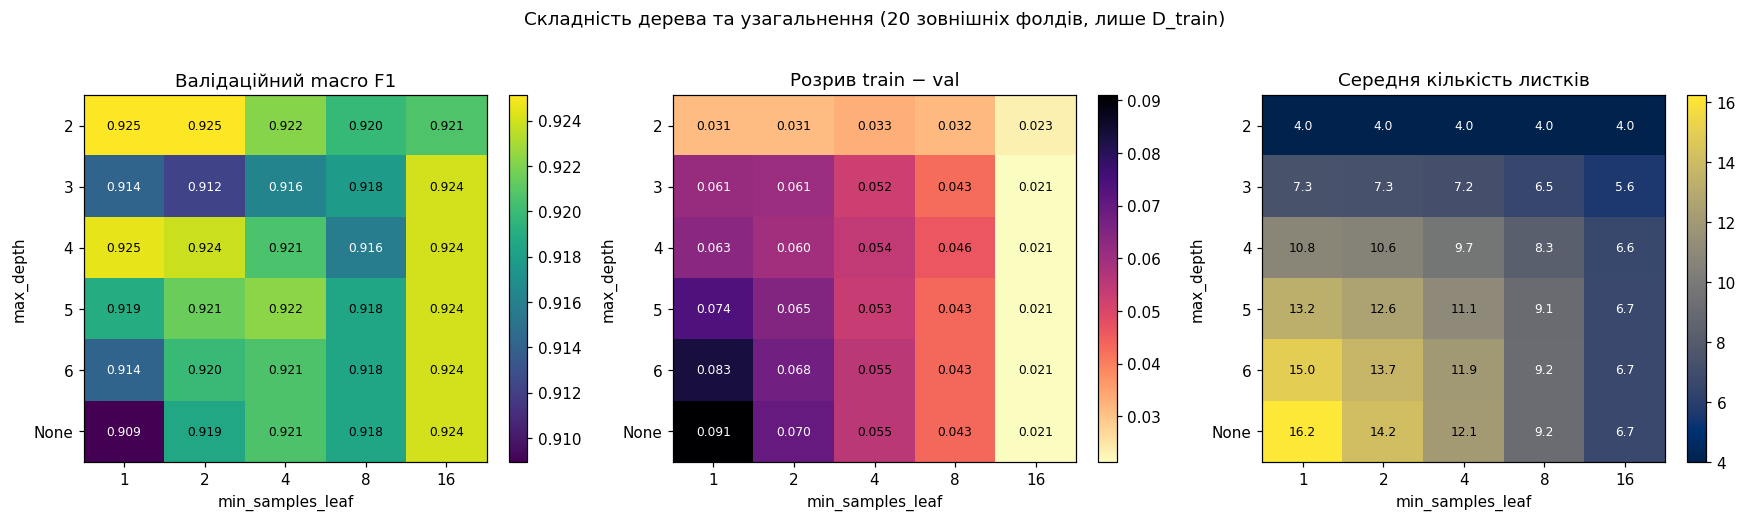

In [7]:
depth_labels = [str(v) for v in TREE_GRID["model__max_depth"]]
msl_labels = TREE_GRID["model__min_samples_leaf"]


def grid_matrix(col):
    return (grid_df.assign(max_depth=grid_df["max_depth"].astype(str))
            .pivot(index="max_depth", columns="min_samples_leaf", values=col)
            .loc[depth_labels, msl_labels].to_numpy())


# (колонка, заголовок, cmap, формат, чи темний колір відповідає низьким значенням)
panels = [("val_f1", "Валідаційний macro F1", "viridis", ".3f", True),
          ("gap", "Розрив train − val", "magma_r", ".3f", False),
          ("mean_leaves", "Середня кількість листків", "cividis", ".1f", True)]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.6))
for ax, (col, title, cmap, fmt, dark_low) in zip(axes, panels):
    M = grid_matrix(col)
    im = ax.imshow(M, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(msl_labels)), msl_labels)
    ax.set_yticks(range(len(depth_labels)), depth_labels)
    ax.set_xlabel("min_samples_leaf")
    ax.set_ylabel("max_depth")
    ax.set_title(title)
    ax.grid(False)
    mid = (M.max() + M.min()) / 2
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            is_dark = (M[i, j] < mid) if dark_low else (M[i, j] > mid)
            ax.text(j, i, format(M[i, j], fmt), ha="center", va="center", fontsize=8,
                    color="white" if is_dark else "black")
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("Складність дерева та узагальнення (20 зовнішніх фолдів, лише D_train)", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "01_tree_complexity_heatmap.png", bbox_inches="tight")
plt.show()

**Рис. 1** (`figures/01_tree_complexity_heatmap.png`, таблиця `results/tree_complexity_grid.csv`).

* **Валідаційний macro F1 майже не залежить від складності**: уся сітка лежить у вузькому діапазоні 0.909–0.925, тоді як std між folds —
  близько 0.03. Різниці між конфігураціями не перевищують шуму.
* **Розрив train − val залежить від складності сильно**: від 0.091 (`max_depth=None`, `min_samples_leaf=1`) до 0.021 (`min_samples_leaf=16`
  при будь-якій глибині ≥ 3). Додаткова складність (до 16 листків) підвищує лише навчальну метрику.
* При `min_samples_leaf=16` обмеження глибини для `max_depth ≥ 4` перестає діяти (дерева практично однакові, ≈ 6.65 листка) —
  мінімальний розмір листка тут діє сильніше, ніж глибина.

### 3.1. Вибір контрольованого дерева (лише на $D_{train}$)

Застосовуємо правило з протоколу (1 SE → мінімальний розрив → менше листків).

> **Застереження.** Параметри обираються за тими самими 20 folds, які пізніше використовуються для порівняння моделей
> (Stage 5), тому оцінка «дерева з фіксованими параметрами» була б **оптимістичною**. Для чесного порівняння в Stage 5 застосовано
> **вкладену крос-валідацію**: внутрішній `GridSearchCV` вибирає параметри лише на навчальній частині кожного зовнішнього fold.

In [8]:
# Правило вибору (зафіксоване в протоколі): val_f1 не гірший за (найкращий − SE), де
# SE = std найкращої конфігурації / sqrt(20); серед таких — мінімальний розрив train−val;
# за рівності — менша кількість листків, потім менша глибина.
best_row = grid_df.loc[grid_df["val_f1"].idxmax()]
se_best = best_row["val_f1_std"] / np.sqrt(len(splits))
cands = grid_df[grid_df["val_f1"] >= best_row["val_f1"] - se_best].copy()
chosen = cands.sort_values(["gap", "mean_leaves", "mean_depth"]).iloc[0]

print(f"Найкраща за val: depth={best_row['max_depth']}, msl={int(best_row['min_samples_leaf'])}, "
      f"val={best_row['val_f1']:.4f}; SE ≈ {se_best:.4f}; поріг відбору = {best_row['val_f1'] - se_best:.4f}")
print(f"Кандидатів у межах 1 SE: {len(cands)} з {len(grid_df)}")
print(cands.sort_values(["gap", "mean_leaves"]).head(6)[["max_depth", "min_samples_leaf", "val_f1", "gap", "mean_leaves"]]
      .round(4).to_string(index=False))

CTRL_PARAMS = dict(
    max_depth=None if chosen["max_depth"] == "None" else int(chosen["max_depth"]),
    min_samples_leaf=int(chosen["min_samples_leaf"]),
)
print("\nОбране контрольоване дерево:", CTRL_PARAMS,
      f"| val F1 = {chosen['val_f1']:.4f}, gap = {chosen['gap']:.4f}, листків ≈ {chosen['mean_leaves']:.1f}")

ctrl_pipe = make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE, **CTRL_PARAMS)).fit(X_train, y_train)
ctrl_tree = ctrl_pipe.named_steps["model"]
print(f"Дерево, навчене на всьому D_train: глибина {ctrl_tree.get_depth()}, листків {ctrl_tree.get_n_leaves()}, "
      f"вузлів {ctrl_tree.tree_.node_count}")
print()
print(export_text(ctrl_tree, feature_names=FEATURES, show_weights=True))

Найкраща за val: depth=2, msl=1, val=0.9251; SE ≈ 0.0075; поріг відбору = 0.9177
Кандидатів у межах 1 SE: 24 з 30
max_depth  min_samples_leaf  val_f1    gap  mean_leaves
        3                16  0.9240 0.0214         5.60
        4                16  0.9240 0.0214         6.60
        5                16  0.9240 0.0214         6.65
        6                16  0.9240 0.0214         6.65
     None                16  0.9240 0.0214         6.65
        2                16  0.9207 0.0234         4.00

Обране контрольоване дерево: {'max_depth': 3, 'min_samples_leaf': 16} | val F1 = 0.9240, gap = 0.0214, листків ≈ 5.6
Дерево, навчене на всьому D_train: глибина 3, листків 7, вузлів 13

|--- radius_worst <= 16.80
|   |--- concave_points_worst <= 0.14
|   |   |--- area_se <= 35.74
|   |   |   |--- weights: [253.00, 2.00] class: 0
|   |   |--- area_se >  35.74
|   |   |   |--- weights: [13.00, 3.00] class: 0
|   |--- concave_points_worst >  0.14
|   |   |--- texture_mean <= 19.71
|   |   |  

**Результат вибору.** Найкращий валідаційний F1 — 0.9251 (`max_depth=2`, `min_samples_leaf=1`), SE ≈ 0.0075, тому в межах «1 SE» опинилося 24 з 30 конфігурацій.
Мінімальний розрив (0.0214) мають конфігурації з `min_samples_leaf=16` і `max_depth ≥ 3`; за рівності обрано найпростішу —
**`max_depth=3`, `min_samples_leaf=16`** (val F1 = 0.9240, ≈ 5.6 листка в folds; на повному $D_{train}$ — глибина 3, 7 листків, 13 вузлів).

> **Чесне застереження.** Вибір не єдиний: «пеньок» глибини 2 має такий самий F1 (0.925) і ще менше листків, але більший розрив (0.031) — правило протоколу його
> відхилило. Вибір контрольованого дерева — це компроміс, а не відкриття: валідаційні якості конфігурацій статистично не розрізняються.

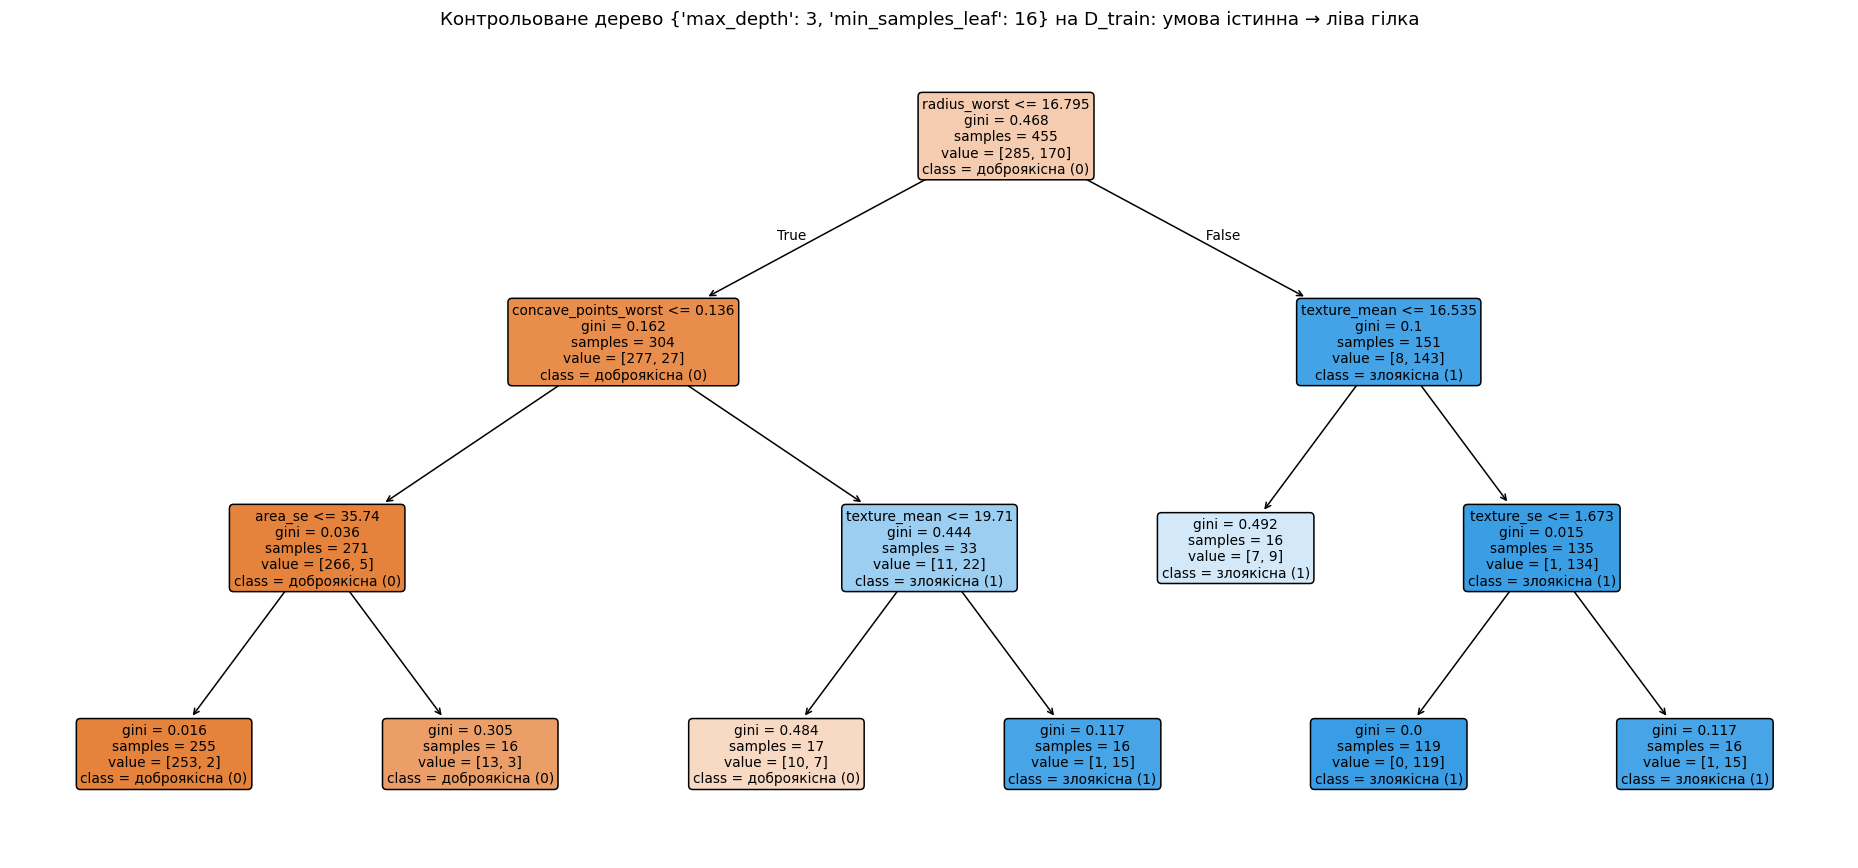

In [9]:
fig, ax = plt.subplots(figsize=(17, 8))
plot_tree(ctrl_tree, feature_names=FEATURES, class_names=["доброякісна (0)", "злоякісна (1)"],
          filled=True, rounded=True, impurity=True, fontsize=9, ax=ax)
ax.set_title(f"Контрольоване дерево {CTRL_PARAMS} на D_train: умова істинна → ліва гілка")
fig.tight_layout()
fig.savefig(FIG / "02_controlled_tree.png", bbox_inches="tight")
plt.show()

**Рис. 2** (`figures/02_controlled_tree.png`): дерево має помірний розмір (13 вузлів), тому показано повністю.

Правила читаються в предметних термінах: **великі ядра** (`radius_worst > 16.8`) у 143 з 151 випадків злоякісні, і чистий листок
(`texture_mean > 16.5`, `texture_se ≤ 1.67`) містить 119 злоякісних і жодного доброякісного; **малі ядра** з низьким `concave_points_worst`
(≤ 0.136) — майже завжди доброякісні (253 : 2 у найбільшому листку). Слабкі місця — **малі листки зі змішаними класами**
(наприклад, `[7, 9]`, `[10, 7]`, `[13, 3]` у 16–17 об'єктах): саме тут дерево нестійке й помиляється (розділ 10).
Дерево використовує лише 5 ознак із 30: `radius_worst`, `concave_points_worst`, `texture_mean`, `area_se`, `texture_se`.

### 3.2. Шлях одного об'єкта в дереві (вручну через `decision_path`)

Беремо один правильно класифікований злоякісний об'єкт $D_{train}$ і відтворюємо шлях від кореня до листка: ознака, поріг,
фактичне значення, напрям переходу, прогноз.

In [10]:
# Вибір об'єкта: серед правильно класифікованих злоякісних об'єктів D_train беремо перший (за позицією)
# з найдовшим шляхом у дереві — щоб шлях був змістовним.
Z_train = ctrl_pipe[:-1].transform(X_train)
pred_train = ctrl_tree.predict(Z_train)
path_len = np.asarray(ctrl_tree.decision_path(Z_train).sum(axis=1)).ravel()
ok_mal = np.where((y_train.values == 1) & (pred_train == 1))[0]
pos = ok_mal[np.argmax(path_len[ok_mal])]
print(f"Об'єкт: індекс {X_train.index[pos]} у вихідній таблиці, справжній клас = {y_train.iloc[pos]} (злоякісна)\n")

row = Z_train[pos:pos + 1]
node_ids = ctrl_tree.decision_path(row).indices
tr = ctrl_tree.tree_
for step, nid in enumerate(node_ids):
    if tr.children_left[nid] == tr.children_right[nid]:   # листок
        counts = tr.value[nid][0]
        pred = int(ctrl_tree.classes_[np.argmax(counts)])
        print(f"Крок {step}: ЛИСТОК #{nid}: {int(tr.n_node_samples[nid])} навчальних об'єктів, "
              f"частка злоякісних = {counts[1] / counts.sum():.3f} -> прогноз = {pred} "
              f"({'злоякісна' if pred == 1 else 'доброякісна'})")
    else:
        f, thr_ = tr.feature[nid], tr.threshold[nid]
        val = row[0, f]
        go_left = val <= thr_
        print(f"Крок {step}: вузол #{nid}: {FEATURES[f]} = {val:.4f} {'<=' if go_left else '> '} {thr_:.4f}  "
              f"-> {'ліва' if go_left else 'права'} гілка")
pipe_pred = int(ctrl_pipe.predict(X_train.iloc[[pos]])[0])
print(f"\nПрогноз пайплайна: {pipe_pred}; збігається з ручним шляхом: {pipe_pred == pred}")

Об'єкт: індекс 432 у вихідній таблиці, справжній клас = 1 (злоякісна)

Крок 0: вузол #0: radius_worst = 22.0300 >  16.7950  -> права гілка
Крок 1: вузол #8: texture_mean = 19.5400 >  16.5350  -> права гілка
Крок 2: вузол #10: texture_se = 1.0010 <= 1.6730  -> ліва гілка
Крок 3: ЛИСТОК #11: 119 навчальних об'єктів, частка злоякісних = 1.000 -> прогноз = 1 (злоякісна)

Прогноз пайплайна: 1; збігається з ручним шляхом: True


Шлях об'єкта (індекс 432, злоякісний): `radius_worst = 22.03 > 16.795` → права гілка; `texture_mean = 19.54 > 16.535` → права гілка;
`texture_se = 1.001 ≤ 1.673` → ліва гілка; **листок #11** (119 навчальних об'єктів, 100 % злоякісних) → прогноз «злоякісна».
Ручний шлях збігається з `predict` пайплайна. Об'єкт далеко від першого порога (22.0 проти 16.8), тому його прогноз не залежить від малих змін порога.

## 4. Ансамблеві моделі (Stage 4)

Параметри обох ансамблів **фіксовані**, а не шукаються сіткою: вибірка мала (455 об'єктів у $D_{train}$), а великий пошук гіперпараметрів
на тих самих folds дав би оптимістичну оцінку й не відповідає змістовним припущенням про складність.

### RandomForestClassifier — паралельний ансамбль (bagging + випадкові підпростори)

| Параметр | Значення | Роль і обґрунтування |
|----------|----------|----------------------|
| `n_estimators` | 300 | Кількість дерев. Зростання числа дерев зменшує дисперсію усереднення, але не збільшує перенавчання; після ~200–300 дерев крива якості виходить на плато, а час росте лінійно |
| `max_features` | `"sqrt"` (≈5 з 30 ознак на розбиття) | Частка ознак у кожному розбитті. Декорелює дерева: за 30 сильно корельованих ознак без обмеження всі дерева починалися б з однієї «розмірної» ознаки |
| `max_depth` | `None` | Дерева вирощуються глибоко (низьке зміщення), дисперсію гасить усереднення |
| `min_samples_leaf` | 1 | Мінімальний розмір листка. Значення 1 — стандарт для RF; контрольна перевірка значень {1, 2, 4} на 5 folds нижче лише підтверджує, що воно не гірше (налаштування на зовнішніх folds не робимо) |
| `bootstrap` | `True` (за замовч.) | Кожне дерево бачить bootstrap-вибірку (~63 % унікальних об'єктів) — джерело різноманітності дерев |
| `random_state` | 42 | Відтворюваність bootstrap та вибору ознак |
| `n_jobs` | −1 | Дерева будуються незалежно — паралелізм не змінює результату |

### HistGradientBoostingClassifier — послідовний ансамбль (градієнтний бустинг)

| Параметр | Значення | Роль і обґрунтування |
|----------|----------|----------------------|
| `max_iter` | 200 | Кількість послідовних неглибоких дерев; кожне виправляє залишкові помилки попередніх. Забагато ітерацій → перенавчання |
| `learning_rate` | 0.05 | Внесок кожного дерева. Мала швидкість + більше ітерацій дає плавніше навчання (компроміс швидкість/якість) |
| `max_leaf_nodes` | 15 | Складність одного дерева-слабкого учня (дерева невеликі, глибина обмежена листками) |
| `min_samples_leaf` | 20 (за замовч.) | Мінімум об'єктів у листку — захист від підгонки під окремі точки на малій вибірці |
| `l2_regularization` | 1.0 | Штраф за великі значення в листках — згладжує ймовірності |
| `early_stopping` | `False` | Кількість ітерацій має бути фіксованою й однаковою у всіх folds (ранню зупинку sklearn вмикає автоматично лише для n > 10 000); так ми вимірюємо складність без прихованого параметра |
| `random_state` | 42 | Для відтворюваності (за відсутності ранньої зупинки та субвибірки модель детермінована) |

Ступінь випадковості різна: у RF випадковість (bootstrap, підмножини ознак) — **джерело якості**; у бустингу без субвибірки
вона мінімальна, стійкість забезпечується малою швидкістю навчання та регуляризацією.

In [11]:
# Контрольна перевірка min_samples_leaf для RF на ПЕРШОМУ повторенні зовнішніх фолдів (5 фолдів).
# Мета — не «налаштування», а перевірка, що фіксоване значення (1) не є очевидно гіршим.
rf_sens = []
for msl in [1, 2, 4]:
    r = cross_validate(make_pipe(RandomForestClassifier(**{**RF_PARAMS, "min_samples_leaf": msl})),
                       X_train, y_train, cv=splits[:5], scoring="f1_macro")
    rf_sens.append({"min_samples_leaf": msl, "mean_f1": r["test_score"].mean(),
                    "std_f1": r["test_score"].std(ddof=1)})
rf_sens = pd.DataFrame(rf_sens)
print(rf_sens.round(4).to_string(index=False))

 min_samples_leaf  mean_f1  std_f1
                1   0.9602  0.0210
                2   0.9554  0.0170
                4   0.9530  0.0139


Контрольна перевірка на 5 folds: `min_samples_leaf = 1 / 2 / 4` дає macro F1 = 0.960 / 0.955 / 0.953 (std між folds 0.014–0.021) — різниці в межах шуму, жодне значення не краще за 1,
тому лишаємо 1 і далі не налаштовуємо. Параметри HistGradientBoosting не перебиралися (одна фіксована конфігурація з обґрунтуванням вище).

## 5. Порівняння якості в однаковій схемі валідації (Stage 5)

Усі моделі оцінюються на **тих самих 20 зовнішніх folds**. Контрольоване дерево — через **вкладену CV** (параметри
обираються всередині кожного fold за внутрішніми 4 folds, `random_state=17`). Для довідки подано також «дерево з параметрами
зі Stage 3» — його оцінка оптимістична, бо параметри обрано за тими самими folds.
Для кожної моделі: середнє, std, мінімум macro F1 за folds, навчальний macro F1, розрив та recall злоякісного класу.
Результати folds збережено в `results/fold_scores.csv`.

In [12]:
fold_rows = []


def add_folds(name, f1_test, f1_train, rec_test, rec_train, extra=None):
    for k, (a, b, c, d) in enumerate(zip(f1_test, f1_train, rec_test, rec_train)):
        row_ = {"model": name, "fold": k, "repeat": k // 5, "f1_test": a, "f1_train": b,
                "recall_test": c, "recall_train": d}
        if extra is not None:
            row_.update({kk: vv[k] for kk, vv in extra.items()})
        fold_rows.append(row_)


# 1) Dummy та дерево без обмежень (вже пораховані на спільних фолдах)
for name, r in [("dummy", res_dummy), ("tree_unrestricted", res_unr)]:
    add_folds(name, r["test_f1"], r["train_f1"], r["test_rec"], r["train_rec"])

# 2) Контрольоване дерево — ВКЛАДЕНА крос-валідація: внутрішній GridSearchCV всередині кожного зовнішнього фолда
def nested_fold(tr_idx, va_idx):
    """Один зовнішній fold: внутрішній GridSearchCV на навчальній частині, оцінка на валідаційній."""
    gs = GridSearchCV(make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE)), TREE_GRID,
                      scoring="f1_macro", cv=inner_cv, refit=True, n_jobs=1)
    Xa, ya = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    Xb, yb = X_train.iloc[va_idx], y_train.iloc[va_idx]
    gs.fit(Xa, ya)
    best = gs.best_estimator_
    return {
        "f1_test": f1_score(yb, best.predict(Xb), average="macro"),
        "f1_train": f1_score(ya, best.predict(Xa), average="macro"),
        "rec_test": recall_score(yb, best.predict(Xb)), "rec_train": recall_score(ya, best.predict(Xa)),
        "depth": best.named_steps["model"].get_depth(), "leaves": best.named_steps["model"].get_n_leaves(),
        "best_max_depth": str(gs.best_params_["model__max_depth"]),
        "best_min_samples_leaf": gs.best_params_["model__min_samples_leaf"],
    }


t0 = time.perf_counter()
# Зовнішні folds незалежні, тому розпаралелюємо їх (результат від цього не змінюється)
nested_res = Parallel(n_jobs=-1, prefer="threads")(delayed(nested_fold)(tr_idx, va_idx) for tr_idx, va_idx in splits)
nested = {k: [r_[k] for r_ in nested_res] for k in nested_res[0]}
print(f"Вкладена CV для дерева (20 зовнішніх × 4 внутрішні × 30 конфігурацій): {time.perf_counter() - t0:.1f} с")
add_folds("tree_controlled", nested["f1_test"], nested["f1_train"], nested["rec_test"], nested["rec_train"],
          extra={k: nested[k] for k in ["depth", "leaves", "best_max_depth", "best_min_samples_leaf"]})

# 3) Ансамблі з фіксованими параметрами
t0 = time.perf_counter()
res_rf = cv_eval(RandomForestClassifier(**RF_PARAMS))
res_hgb = cv_eval(HistGradientBoostingClassifier(**HGB_PARAMS))
print(f"RF + HGB на 20 фолдах: {time.perf_counter() - t0:.1f} с")
for name, r in [("random_forest", res_rf), ("hist_gb", res_hgb)]:
    add_folds(name, r["test_f1"], r["train_f1"], r["test_rec"], r["train_rec"])

# 4) Довідково: дерево з параметрами зі Stage 3 (обрані на ТИХ САМИХ фолдах — оцінка оптимістична)
res_fixed = cv_eval(DecisionTreeClassifier(random_state=RANDOM_STATE, **CTRL_PARAMS))
add_folds("tree_fixed_stage3", res_fixed["test_f1"], res_fixed["train_f1"], res_fixed["test_rec"],
          res_fixed["train_rec"])

folds_df = pd.DataFrame(fold_rows)
folds_df.to_csv(RES / "fold_scores.csv", index=False)

order = ["dummy", "tree_unrestricted", "tree_controlled", "tree_fixed_stage3", "random_forest", "hist_gb"]
summ = pd.DataFrame({
    "F1 mean": folds_df.groupby("model")["f1_test"].mean(),
    "F1 std": folds_df.groupby("model")["f1_test"].std(ddof=1),
    "F1 min": folds_df.groupby("model")["f1_test"].min(),
    "F1 train": folds_df.groupby("model")["f1_train"].mean(),
    "recall(M) val": folds_df.groupby("model")["recall_test"].mean(),
    "recall(M) min": folds_df.groupby("model")["recall_test"].min(),
    "recall(M) train": folds_df.groupby("model")["recall_train"].mean(),
}).loc[order]
summ.insert(4, "gap", summ["F1 train"] - summ["F1 mean"])
summ.to_csv(RES / "model_comparison_summary.csv")
print(summ.round(4).to_string())

print("\nЧастота обраних гіперпараметрів у вкладеній CV (20 зовнішніх фолдів):")
nest_df = folds_df[folds_df["model"] == "tree_controlled"]
print(nest_df.groupby(["best_max_depth", "best_min_samples_leaf"]).size().sort_values(ascending=False).to_string())
print("Середні глибина / листки дерев із вкладеної CV:", nest_df[["depth", "leaves"]].mean().round(2).to_dict())

Вкладена CV для дерева (20 зовнішніх × 4 внутрішні × 30 конфігурацій): 33.9 с


RF + HGB на 20 фолдах: 20.3 с


                   F1 mean  F1 std  F1 min  F1 train     gap  recall(M) val  recall(M) min  recall(M) train
model                                                                                                      
dummy               0.3851  0.0000  0.3851    0.3851  0.0000         0.0000         0.0000           0.0000
tree_unrestricted   0.9089  0.0262  0.8499    1.0000  0.0911         0.8971         0.8235           1.0000
tree_controlled     0.9187  0.0325  0.8554    0.9782  0.0595         0.8882         0.7647           0.9614
tree_fixed_stage3   0.9240  0.0317  0.8444    0.9454  0.0214         0.9206         0.7647           0.9382
random_forest       0.9589  0.0167  0.9304    1.0000  0.0411         0.9441         0.8824           1.0000
hist_gb             0.9646  0.0187  0.9296    1.0000  0.0354         0.9426         0.8824           1.0000

Частота обраних гіперпараметрів у вкладеній CV (20 зовнішніх фолдів):
best_max_depth  best_min_samples_leaf
2               8.0        

**Таблиця fold-оцінок** (`results/fold_scores.csv`, підсумок — `results/model_comparison_summary.csv`):

* **Dummy** — 0.385. **Дерево без обмежень** — 0.909 ± 0.026 (min 0.850), train 1.000, розрив 0.091.
* **Контрольоване дерево (вкладена CV)** — 0.919 ± 0.033 (min 0.855), train 0.978, розрив 0.060, recall злоякісних 0.888 (min 0.765).
  Оцінка «з параметрами зі Stage 3» (0.924) на 0.005 вища — це розмір оптимізму від вибору параметрів на тих самих folds.
* **Random Forest** — 0.959 ± 0.017 (min 0.930), train 1.000, розрив 0.041, recall 0.944 (min 0.882).
* **HistGradientBoosting** — 0.965 ± 0.019 (min 0.930), train 1.000, розрив 0.035, recall 0.943.

**Вкладена CV показала нестабільність налаштування дерева:** у 20 зовнішніх folds внутрішній пошук обрав 12 різних комбінацій параметрів
(жодна не повторилася більше ніж у 3 folds; середня глибина 4.1, ≈ 10 листків) — на плато майже однакової якості «найкращих» конфігурацій багато.
Ансамблі мають train F1 = 1.0, але це не свідчить про гірше узагальнення: їхній валідаційний F1 вищий, а recall злоякісних — на ≈ 5.6 п.п. вищий (менше пропущених злоякісних).

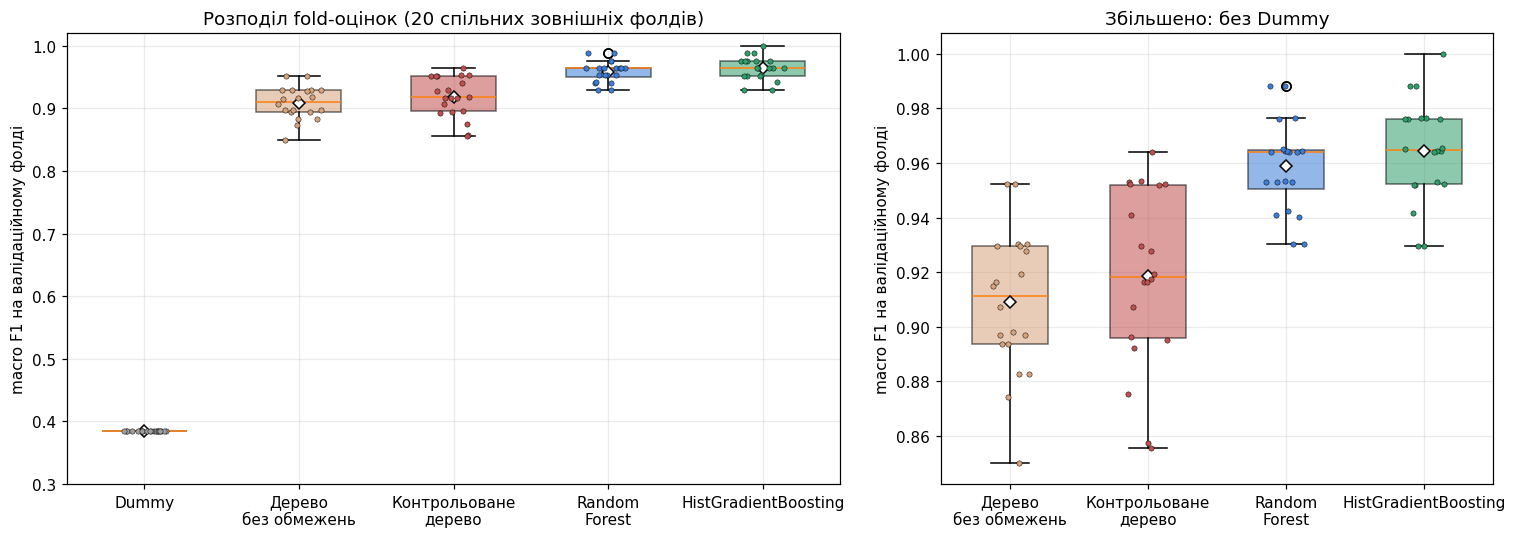

In [13]:
plot_models = ["dummy", "tree_unrestricted", "tree_controlled", "random_forest", "hist_gb"]
zoom = ["tree_unrestricted", "tree_controlled", "random_forest", "hist_gb"]
rng_j = np.random.default_rng(RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [1.4, 1]})
for ax, group, title in [(axes[0], plot_models, "Розподіл fold-оцінок (20 спільних зовнішніх фолдів)"),
                         (axes[1], zoom, "Збільшено: без Dummy")]:
    data = [folds_df.loc[folds_df["model"] == m_, "f1_test"].to_numpy() for m_ in group]
    bp = ax.boxplot(data, tick_labels=[LABELS[m_].replace(" ", "\n", 1) for m_ in group], patch_artist=True,
                    widths=0.55, showmeans=True,
                    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black"))
    for i, (patch, m_, d) in enumerate(zip(bp["boxes"], group, data)):
        patch.set_facecolor(COLORS[m_])
        patch.set_alpha(0.55)
        ax.scatter(np.full(len(d), i + 1) + rng_j.uniform(-0.15, 0.15, len(d)), d, s=12, color=COLORS[m_],
                   edgecolor="black", linewidth=0.3, zorder=3)
    ax.set_ylabel("macro F1 на валідаційному фолді")
    ax.set_title(title)
axes[0].set_ylim(0.3, 1.02)
fig.tight_layout()
fig.savefig(FIG / "03_fold_scores_boxplot.png", bbox_inches="tight")
plt.show()

**Рис. 3** (`figures/03_fold_scores_boxplot.png`). Розподіли дерев ширші (діапазон ≈ 0.85–0.97), ансамблів — вужчі й зміщені вгору. Інтервали **частково перекриваються**
(кращі folds дерева порівнянні з гіршими folds ансамблів), тому порівнюємо ще й **парно** — на тих самих folds (таблиця нижче).
Між RF і HistGB переможця **не оголошуємо**: різниця 0.006 набагато менша за std (0.017–0.019), а у 50 % folds кращий RF.

In [14]:
def fold_vec(name):
    return folds_df.loc[folds_df["model"] == name].sort_values("fold")["f1_test"].to_numpy()


pairs = [("random_forest", "tree_controlled"), ("hist_gb", "tree_controlled"), ("hist_gb", "random_forest"),
         ("random_forest", "tree_unrestricted")]
pr = []
for a, b in pairs:
    d = fold_vec(a) - fold_vec(b)
    pr.append({"A − B": f"{LABELS[a]} − {LABELS[b]}", "mean Δ": d.mean(), "std Δ": d.std(ddof=1),
               "частка фолдів A>B": (d > 0).mean(), "частка A=B": (d == 0).mean()})
print(pd.DataFrame(pr).round(4).to_string(index=False))

# Перевірка гіпотез H1 та H3
m = summ["F1 mean"]
sd = summ["F1 std"]
H1_diff = m["random_forest"] - m["tree_controlled"]
H1_ok = bool(H1_diff > sd["tree_controlled"])
print(f"\nH1: mean(RF) − mean(контрольоване дерево, вкладена CV) = {H1_diff:.4f}; "
      f"std(дерева) = {sd['tree_controlled']:.4f} -> {'ПІДТВЕРДЖЕНО' if H1_ok else 'НЕ ПІДТВЕРДЖЕНО'}")
print(f"    (довідково: HGB − дерево = {m['hist_gb'] - m['tree_controlled']:.4f})")

g_unr = summ.loc["tree_unrestricted", "gap"]
g_ctrl_nested = summ.loc["tree_controlled", "gap"]
g_ctrl_fixed = summ.loc["tree_fixed_stage3", "gap"]
H3_ok = bool((g_ctrl_nested < g_unr) and (g_ctrl_fixed < g_unr))
print(f"H3: розрив train−val: без обмежень = {g_unr:.4f}; контрольоване (вкладена CV) = {g_ctrl_nested:.4f}; "
      f"контрольоване (фікс. параметри) = {g_ctrl_fixed:.4f} -> {'ПІДТВЕРДЖЕНО' if H3_ok else 'НЕ ПІДТВЕРДЖЕНО'}")
print(f"    але val F1: без обмежень {m['tree_unrestricted']:.4f} vs контрольоване {m['tree_controlled']:.4f}")

# Ансамбль-кандидат (правило з протоколу)
ENS = "random_forest"
if m["hist_gb"] - m["random_forest"] > sd["random_forest"]:
    ENS = "hist_gb"
print(f"\nАнсамбль-кандидат за правилом протоколу: {LABELS[ENS]} "
      f"(HGB − RF = {m['hist_gb'] - m['random_forest']:+.4f}; std RF = {sd['random_forest']:.4f})")

                                      A − B  mean Δ  std Δ  частка фолдів A>B  частка A=B
       Random Forest − Контрольоване дерево  0.0402 0.0261               0.95        0.00
HistGradientBoosting − Контрольоване дерево  0.0459 0.0294               0.95        0.00
       HistGradientBoosting − Random Forest  0.0057 0.0191               0.50        0.05
        Random Forest − Дерево без обмежень  0.0499 0.0255               1.00        0.00

H1: mean(RF) − mean(контрольоване дерево, вкладена CV) = 0.0402; std(дерева) = 0.0325 -> ПІДТВЕРДЖЕНО
    (довідково: HGB − дерево = 0.0459)
H3: розрив train−val: без обмежень = 0.0911; контрольоване (вкладена CV) = 0.0595; контрольоване (фікс. параметри) = 0.0214 -> ПІДТВЕРДЖЕНО
    але val F1: без обмежень 0.9089 vs контрольоване 0.9187

Ансамбль-кандидат за правилом протоколу: Random Forest (HGB − RF = +0.0057; std RF = 0.0167)


**Вердикти.**

* **H1 — ПІДТВЕРДЖЕНО, але з малим запасом:** Δ = 0.040 проти std дерева 0.033 (відношення ≈ 1.2). Парно RF кращий за контрольоване дерево у 19 з 20 folds (середня Δ = 0.040, std Δ = 0.026).
* **H3 — ПІДТВЕРДЖЕНО:** розрив 0.091 (без обмежень) → 0.060 (вкладена CV) і 0.021 (фіксовані параметри). **Застереження:** розрив зменшився здебільшого через падіння
  навчальної метрики (1.000 → 0.978), а валідаційна зросла лише з 0.909 до 0.919 (в межах шуму). Менший розрив ≠ краща узагальнювальна здатність.
  Розбіжність між 0.060 і 0.021 показує, що внутрішній пошук часто обирає глибші дерева, ніж дерево, обране за 20 folds зі Stage 3.
* **Ансамбль-кандидат за правилом протоколу — Random Forest:** HGB лише на 0.006 вищий, а std RF — 0.017.

> Fold-оцінки з повторної CV не є незалежними (навчальні вибірки перекриваються), тому std та парні частки — описові статистики, а не формальні p-значення.

## 6. Стійкість як властивість ML-рішення (Stage 6)

Гіперпараметри **фіксовані** (контрольоване дерево — з Stage 3). Повторюємо 5-fold CV для **11 значень** `random_state`
розбиття `StratifiedKFold` (42…52; непарна кількість, щоб консенсус не мав нічиєї). Для кожного повторення:

* $q$ = середній macro F1 за 5 folds; далі $\bar q$, $s_q$, $\min q$, $\max q$ по повтореннях;
* OOF-прогноз для кожного об'єкта $D_{train}$ (прогноз, отриманий моделлю, що **не бачила** цей об'єкт).

Для об'єкта: **консенсусний клас** — мажоритарний за 11 OOF-прогнозами; **нестабільність** — частка повторень, де прогноз ≠ консенсусу.
Об'єкт вважаємо **нестійким**, якщо його прогноз відрізнявся від консенсусу у **> 25 %** повторень (≥ 3 з 11).

> Параметри дерева обрано за folds із фіксованим `random_state=42`, тож для дерева результат цього етапу трохи оптимістичний;
> для ансамблів параметри не підбиралися.

In [15]:
SEEDS = list(range(42, 53))   # 11 значень random_state розбиття (непарна кількість -> консенсус без нічиєї)
FACTORIES = {
    "dummy": lambda: make_pipe(DummyClassifier(strategy="most_frequent")),
    "tree_unrestricted": lambda: make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE)),
    "tree_controlled": lambda: make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE, **CTRL_PARAMS)),
    "random_forest": lambda: make_pipe(RandomForestClassifier(**RF_PARAMS)),
    "hist_gb": lambda: make_pipe(HistGradientBoostingClassifier(**HGB_PARAMS)),
}

oof_preds = {m_: np.zeros((len(SEEDS), len(X_train)), dtype=int) for m_ in FACTORIES}
q_rows = []
t0 = time.perf_counter()
for si, seed in enumerate(SEEDS):
    fold_split = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=seed).split(X_train, y_train))
    for name, factory in FACTORIES.items():
        fold_f1, fold_rec = [], []
        for tr_idx, va_idx in fold_split:
            est = factory().fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
            p = est.predict(X_train.iloc[va_idx])
            oof_preds[name][si, va_idx] = p
            fold_f1.append(f1_score(y_train.iloc[va_idx], p, average="macro"))
            fold_rec.append(recall_score(y_train.iloc[va_idx], p))
        q_rows.append({"seed": seed, "model": name, "q_macro_f1": np.mean(fold_f1),
                       "recall_malignant": np.mean(fold_rec),
                       "oof_macro_f1": f1_score(y_train, oof_preds[name][si], average="macro")})
print(f"Stage 6 (11 розбиттів × 5 фолдів × 5 моделей): {time.perf_counter() - t0:.1f} с")

q_df = pd.DataFrame(q_rows)
q_df.to_csv(RES / "seed_stability_scores.csv", index=False)
q_sum = q_df.groupby("model")["q_macro_f1"].agg(
    mean="mean", std=lambda s: s.std(ddof=1), min="min", max="max").loc[list(FACTORIES)]
q_sum["range"] = q_sum["max"] - q_sum["min"]
print(q_sum.round(4).to_string())

Stage 6 (11 розбиттів × 5 фолдів × 5 моделей): 52.6 с
                     mean     std     min     max   range
model                                                    
dummy              0.3851  0.0000  0.3851  0.3851  0.0000
tree_unrestricted  0.9195  0.0105  0.9043  0.9340  0.0297
tree_controlled    0.9196  0.0094  0.9018  0.9315  0.0297
random_forest      0.9555  0.0063  0.9455  0.9672  0.0217
hist_gb            0.9575  0.0092  0.9384  0.9670  0.0286


In [16]:
stab_rows = []
oof_wide = pd.DataFrame({"index": X_train.index, "y_true": y_train.values})
dis_rate = {}
for name in FACTORIES:
    P_ = oof_preds[name]                          # (n_seeds, n_objects)
    consensus = (P_.mean(axis=0) > 0.5).astype(int)
    rate = (P_ != consensus).mean(axis=0)         # частка повторень, де прогноз ≠ консенсусу
    dis_rate[name] = rate
    oof_wide[f"{name}_consensus"] = consensus
    oof_wide[f"{name}_disagree_rate"] = rate
    stab_rows.append({
        "model": name,
        "mean_disagreement_rate": rate.mean(),
        "objects_ever_changed": int((rate > 0).sum()),
        "objects_unstable_gt25pct": int((rate > 0.25).sum()),
        "consensus_macro_f1": f1_score(y_train, consensus, average="macro"),
    })
stab_df = pd.DataFrame(stab_rows).set_index("model")
stab_df.to_csv(RES / "prediction_stability_summary.csv")
seed_cols = {f"{name}_seed{seed}": oof_preds[name][si] for name in FACTORIES for si, seed in enumerate(SEEDS)}
oof_wide = pd.concat([oof_wide, pd.DataFrame(seed_cols)], axis=1)
oof_wide.to_csv(RES / "oof_predictions_seeds.csv", index=False)

min_cnt = int(np.floor(0.25 * len(SEEDS))) + 1
print(f"Об'єктів D_train: {len(X_train)}; повторень: {len(SEEDS)}; «нестійкий» = прогноз ≠ консенсусу "
      f"у > 25% повторень, тобто щонайменше {min_cnt} з {len(SEEDS)}")
print(stab_df.round(4).to_string())

rf_rate, tree_rate = stab_df.loc["random_forest", "mean_disagreement_rate"], stab_df.loc["tree_controlled", "mean_disagreement_rate"]
ratio = tree_rate / rf_rate if rf_rate > 0 else np.inf
H2_ok = bool(ratio >= 3)
print(f"\nH2: частка розбіжностей: контрольоване дерево = {tree_rate:.4f}, RF = {rf_rate:.4f}, "
      f"відношення дерево/RF = {ratio:.2f} (потрібно ≥ 3) -> {'ПІДТВЕРДЖЕНО' if H2_ok else 'НЕ ПІДТВЕРДЖЕНО'}")
hgb_rate = stab_df.loc["hist_gb", "mean_disagreement_rate"]
print(f"    довідково: HGB = {hgb_rate:.4f}; відношення дерево/HGB = {tree_rate / hgb_rate if hgb_rate > 0 else np.inf:.2f}")

Об'єктів D_train: 455; повторень: 11; «нестійкий» = прогноз ≠ консенсусу у > 25% повторень, тобто щонайменше 3 з 11
                   mean_disagreement_rate  objects_ever_changed  objects_unstable_gt25pct  consensus_macro_f1
model                                                                                                        
dummy                              0.0000                     0                         0              0.3851
tree_unrestricted                  0.0492                    95                        46              0.9390
tree_controlled                    0.0356                    68                        33              0.9344
random_forest                      0.0094                    18                         7              0.9600
hist_gb                            0.0126                    29                         8              0.9646

H2: частка розбіжностей: контрольоване дерево = 0.0356, RF = 0.0094, відношення дерево/RF = 3.79 (потрібно ≥ 3) -

**Стійкість метрики (11 розбиттів).**

| Модель | $\bar q$ | $s_q$ | min $q$ | max $q$ |
|---|---|---|---|---|
| Дерево без обмежень | 0.9195 | 0.0105 | 0.9043 | 0.9340 |
| Контрольоване дерево | 0.9196 | 0.0094 | 0.9018 | 0.9315 |
| Random Forest | 0.9555 | 0.0063 | 0.9455 | 0.9672 |
| HistGradientBoosting | 0.9575 | 0.0092 | 0.9384 | 0.9670 |

Випадкове розбиття змінює $q$ на 0.02–0.03 (діапазон) для кожної моделі. Практичний висновок «ансамбль краще за дерево» при цьому **не змінюється**:
мінімум RF (0.9455) і HGB (0.9384) вищий за максимум контрольованого дерева (0.9315). Діапазони RF і HGB перекриваються — розрізнити їх за цим показником неможливо.

**Стійкість прогнозів** (`results/prediction_stability_summary.csv`, `results/oof_predictions_seeds.csv`; «нестійкий» — розбіжність із консенсусом у ≥ 3 з 11 повторень):

| Модель | середня розбіжність | об'єктів, що хоч раз змінилися | нестійких (> 25 %) | macro F1 консенсусу |
|---|---|---|---|---|
| Дерево без обмежень | 4.92 % | 95 | 46 | 0.939 |
| Контрольоване дерево | 3.56 % | 68 | 33 | 0.934 |
| Random Forest | 0.94 % | 18 | 7 | 0.960 |
| HistGradientBoosting | 1.26 % | 29 | 8 | 0.965 |

* **H2 — ПІДТВЕРДЖЕНО:** відношення дерево / RF = 3.79 (≥ 3). Для HGB відношення — 2.83, тобто за тим самим правилом воно **не** пройшло б; запас у RF невеликий.
* Нестійких об'єктів у контрольованого дерева 33 з 455 (7.3 %), у RF — 7 (1.5 %).
* Консенсус ансамблів точніший за консенсус дерев (0.960–0.965 проти 0.934–0.939): ансамбль не лише стабільніший, а й стабільніше правильний.

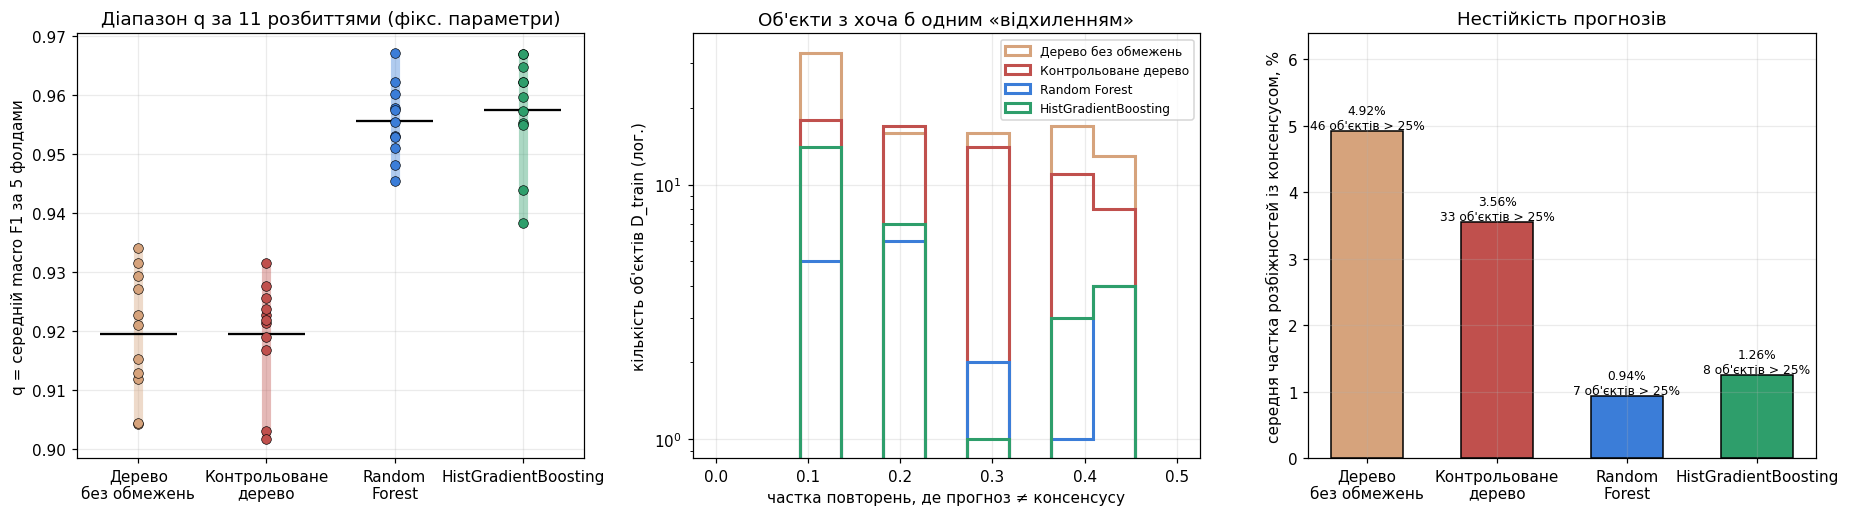

In [17]:
show = ["tree_unrestricted", "tree_controlled", "random_forest", "hist_gb"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

ax = axes[0]
for i, m_ in enumerate(show):
    v = q_df.loc[q_df["model"] == m_, "q_macro_f1"].to_numpy()
    ax.vlines(i, v.min(), v.max(), color=COLORS[m_], linewidth=6, alpha=0.4)
    ax.scatter(np.full(len(v), i), v, color=COLORS[m_], s=40, edgecolor="black", linewidth=0.4, zorder=3)
    ax.hlines(v.mean(), i - 0.3, i + 0.3, color="black", linewidth=1.5)
ax.set_xticks(range(len(show)), [LABELS[m_].replace(" ", "\n", 1) for m_ in show])
ax.set_ylabel("q = середній macro F1 за 5 фолдами")
ax.set_title(f"Діапазон q за {len(SEEDS)} розбиттями (фікс. параметри)")

ax = axes[1]
bins = np.linspace(0, 0.5, 12)
for m_ in show:
    ax.hist(dis_rate[m_][dis_rate[m_] > 0], bins=bins, histtype="step", linewidth=2, color=COLORS[m_], label=LABELS[m_])
ax.set_yscale("log")
ax.set_xlabel("частка повторень, де прогноз ≠ консенсусу")
ax.set_ylabel("кількість об'єктів D_train (лог.)")
ax.set_title("Об'єкти з хоча б одним «відхиленням»")
ax.legend(fontsize=8)

ax = axes[2]
xs = np.arange(len(show))
ax.bar(xs, [stab_df.loc[m_, "mean_disagreement_rate"] * 100 for m_ in show], 0.55,
       color=[COLORS[m_] for m_ in show], edgecolor="black")
for x_, m_ in zip(xs, show):
    ax.text(x_, stab_df.loc[m_, "mean_disagreement_rate"] * 100 + 0.03,
            f"{stab_df.loc[m_, 'mean_disagreement_rate'] * 100:.2f}%\n{int(stab_df.loc[m_, 'objects_unstable_gt25pct'])} об'єктів > 25%",
            ha="center", fontsize=8)
ax.set_xticks(xs, [LABELS[m_].replace(" ", "\n", 1) for m_ in show])
ax.set_ylabel("середня частка розбіжностей із консенсусом, %")
ax.set_title("Нестійкість прогнозів")
ax.set_ylim(0, max(stab_df.loc[show, "mean_disagreement_rate"]) * 100 * 1.3)
fig.tight_layout()
fig.savefig(FIG / "04_seed_and_prediction_stability.png", bbox_inches="tight")
plt.show()

**Рис. 4** (`figures/04_seed_and_prediction_stability.png`). Ліворуч — діапазон $q$: хмари точок дерев і ансамблів не перетинаються. Посередині (логарифмічна шкала) — розподіл нестабільності серед
об'єктів, які хоч раз відхилилися від консенсусу: у дерев таких об'єктів більше на кожному рівні, а об'єктів із нестабільністю 0.3–0.45 (тобто «майже коло») у ансамблів одиниці.
Праворуч — середня частка розбіжностей і кількість об'єктів > 25 %. Висновок: різниця між деревом та ансамблем — це не лише різниця середніх, а й **різна чутливість окремого прогнозу
до складу навчальної вибірки**.

## 7. Стійкість структури дерева (Stage 7)

Генеруємо **200 bootstrap-вибірок** з $D_{train}$ (`np.random.default_rng(42)`, вибірка з поверненням розміру 455) і
на кожній навчаємо дерево з **тими самими параметрами**, що й контрольоване. Фіксуємо кореневу ознаку, поріг кореня, глибину,
кількість листків та ознаки другого рівня. Детально — `results/bootstrap_trees.csv`.

In [18]:
N_BOOT = 200
rng = np.random.default_rng(RANDOM_STATE)
boot_rows = []
for b in range(N_BOOT):
    idx = rng.integers(0, len(X_train), len(X_train))
    est = make_pipe(DecisionTreeClassifier(random_state=RANDOM_STATE, **CTRL_PARAMS)).fit(
        X_train.iloc[idx], y_train.iloc[idx])
    t_ = est.named_steps["model"].tree_
    left, right = t_.children_left[0], t_.children_right[0]
    lvl2 = [FEATURES[t_.feature[c]] if t_.children_left[c] != -1 else "—" for c in (left, right)]
    boot_rows.append({
        "boot": b, "root_feature": FEATURES[t_.feature[0]], "root_threshold": t_.threshold[0],
        "depth": est.named_steps["model"].get_depth(), "leaves": est.named_steps["model"].get_n_leaves(),
        "left_child_feature": lvl2[0], "right_child_feature": lvl2[1],
        "n_unique_objects": len(np.unique(idx)),
    })
boot_df = pd.DataFrame(boot_rows)
boot_df.to_csv(RES / "bootstrap_trees.csv", index=False)

root_freq = boot_df["root_feature"].value_counts()
print((root_freq / N_BOOT).round(3).to_string())
dom = root_freq.index[0]
dom_share = root_freq.iloc[0] / N_BOOT
H4_ok = bool(dom_share < 0.8)
print(f"\nДомінантна коренева ознака: {dom}, частка {dom_share:.3f} -> "
      f"H4 (частка < 0.80): {'ПІДТВЕРДЖЕНО' if H4_ok else 'НЕ ПІДТВЕРДЖЕНО'}")
print(f"Глибина: {boot_df['depth'].value_counts().sort_index().to_dict()}; "
      f"листків: середнє {boot_df['leaves'].mean():.2f}, діапазон {boot_df['leaves'].min()}–{boot_df['leaves'].max()}")
root_full = FEATURES[ctrl_tree.tree_.feature[0]]
print(f"Дерево на повному D_train: корінь = {root_full} при порозі {ctrl_tree.tree_.threshold[0]:.4f}")

thr_dom = boot_df.loc[boot_df["root_feature"] == dom, "root_threshold"]
print(f"\nПоріг для {dom} (n={len(thr_dom)}): mean={thr_dom.mean():.4f}, std={thr_dom.std(ddof=1):.4f}, "
      f"CV={thr_dom.std(ddof=1) / thr_dom.mean():.4f}, min={thr_dom.min():.4f}, max={thr_dom.max():.4f}, "
      f"IQR={thr_dom.quantile(.75) - thr_dom.quantile(.25):.4f}")
print(f"Розкид ознаки {dom} у D_train: 5%–95% = [{X_train[dom].quantile(.05):.3f}, {X_train[dom].quantile(.95):.3f}]; "
      f"std = {X_train[dom].std():.3f}")

# Сімейство корельованих «конкурентів» домінантної ознаки (|ρ| >= 0.9 на D_train)
family = [f for f in FEATURES if f != dom and abs(corr_train.loc[dom, f]) >= 0.9]
fam_share = boot_df["root_feature"].isin([dom] + family).mean()
print(f"\nОзнаки з |ρ| ≥ 0.9 до {dom}: {family}")
print(f"Частка bootstrap-дерев, чий корінь — {dom} або його корельований «конкурент»: {fam_share:.3f}")
size_share = boot_df["root_feature"].isin(SIZE_GROUP).mean()
conc_share = boot_df["root_feature"].isin(CONC_GROUP).mean()
print(f"Корінь із «розмірного» сімейства (radius/perimeter/area): {size_share:.3f}; "
      f"із «увігнутого» (concavity/concave_points): {conc_share:.3f}; решта: {1 - size_share - conc_share:.3f}")
print("\nОзнаки на другому рівні (ліва та права дитина кореня), частота:")
print(pd.concat([boot_df["left_child_feature"], boot_df["right_child_feature"]]).value_counts().head(8).to_string())

root_feature
perimeter_worst         0.450
concave_points_worst    0.280
radius_worst            0.115
concave_points_mean     0.085
area_worst              0.070

Домінантна коренева ознака: perimeter_worst, частка 0.450 -> H4 (частка < 0.80): ПІДТВЕРДЖЕНО
Глибина: {3: 200}; листків: середнє 5.58, діапазон 4–7
Дерево на повному D_train: корінь = radius_worst при порозі 16.7950

Поріг для perimeter_worst (n=90): mean=107.8789, std=4.1554, CV=0.0385, min=101.4500, max=115.4500, IQR=7.9000
Розкид ознаки perimeter_worst у D_train: 5%–95% = [67.868, 171.370]; std = 33.195

Ознаки з |ρ| ≥ 0.9 до perimeter_worst: ['radius_mean', 'perimeter_mean', 'area_mean', 'radius_worst', 'area_worst']
Частка bootstrap-дерев, чий корінь — perimeter_worst або його корельований «конкурент»: 0.635
Корінь із «розмірного» сімейства (radius/perimeter/area): 0.635; із «увігнутого» (concavity/concave_points): 0.365; решта: 0.000

Ознаки на другому рівні (ліва та права дитина кореня), частота:
concave_points_worst

**Частоти кореневих ознак у 200 bootstrap-деревах** (`results/bootstrap_trees.csv`):

| Коренева ознака | Частка |
|---|---|
| `perimeter_worst` | 45.0 % |
| `concave_points_worst` | 28.0 % |
| `radius_worst` | 11.5 % |
| `concave_points_mean` | 8.5 % |
| `area_worst` | 7.0 % |

* **H4 — ПІДТВЕРДЖЕНО:** найчастіша ознака — лише 45 % (< 80 %). Дерево на повному $D_{train}$ має корінь `radius_worst`, а це лише **11.5 %** bootstrap-дерев:
  намальоване дерево — один із багатьох майже рівноцінних описів.
* Корінь завжди походить із двох «сімейств»: розмірного (`perimeter/radius/area`, 63.5 %) та увігнутості (`concave_points`, 36.5 %). Усередині сімейства ознаки майже дублюють
  одна одну ($|\rho|$ 0.94–0.99), тому вибір між ними визначається дрібними відмінностями вибірки — це пояснює нестабільність.
* **Порог домінантної ознаки стабільний:** для `perimeter_worst` середнє 107.9, std 4.2 (CV 3.8 %, діапазон 101.5–115.5), тобто ≈ 0.13 std самої ознаки (33.2).
  Нестабільна **ознака**, а не поріг.
* Глибина завжди 3 (обмеження), кількість листків 4–7 (у середньому 5.6). Ознаки другого рівня теж змінюються (`concave_points_worst`, `area_worst`, `texture_*`).

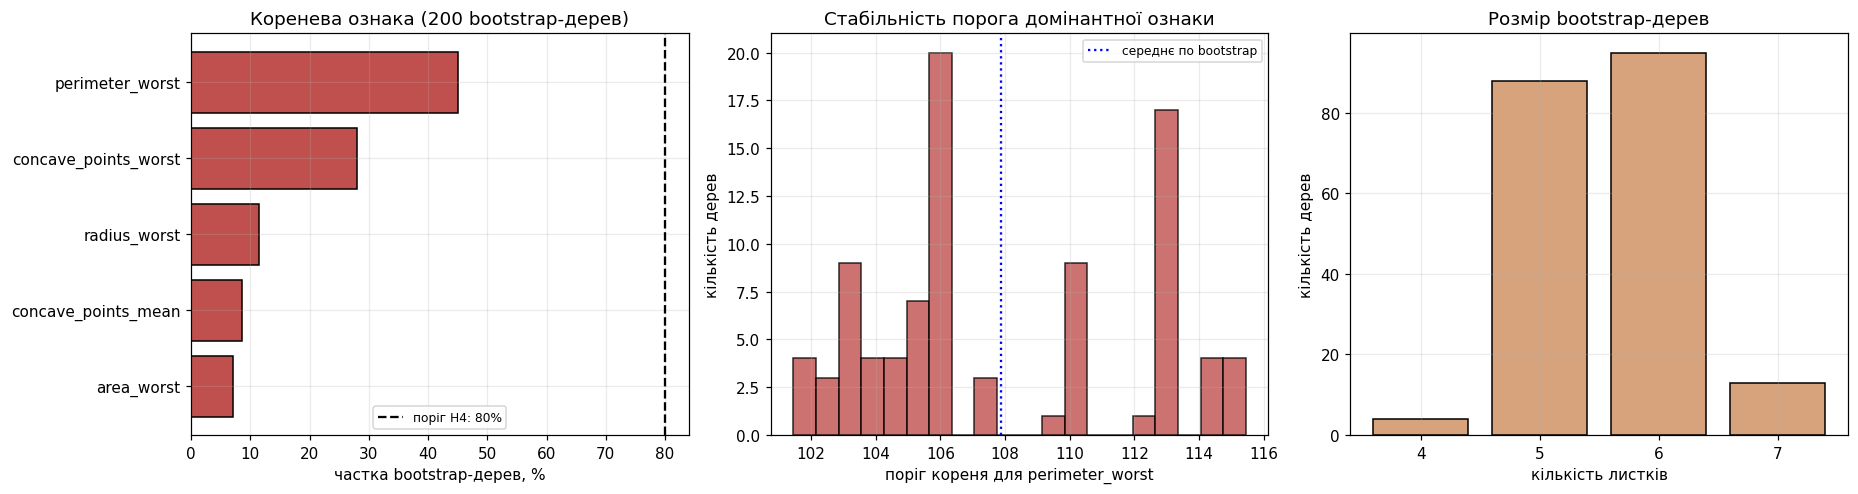

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))
ax = axes[0]
rf_ = root_freq / N_BOOT * 100
ax.barh(rf_.index[::-1], rf_.values[::-1], color="#c0504d", edgecolor="black")
ax.axvline(80, color="black", linestyle="--", label="поріг H4: 80%")
ax.set_xlabel("частка bootstrap-дерев, %")
ax.set_title(f"Коренева ознака ({N_BOOT} bootstrap-дерев)")
ax.legend(fontsize=8)

ax = axes[1]
ax.hist(thr_dom, bins=20, color="#c0504d", edgecolor="black", alpha=0.8)
if root_full == dom:
    ax.axvline(ctrl_tree.tree_.threshold[0], color="black", linestyle="--", label="поріг на повному D_train")
ax.axvline(thr_dom.mean(), color="blue", linestyle=":", label="середнє по bootstrap")
ax.set_xlabel(f"поріг кореня для {dom}")
ax.set_ylabel("кількість дерев")
ax.set_title("Стабільність порога домінантної ознаки")
ax.legend(fontsize=8)

ax = axes[2]
vc = boot_df["leaves"].value_counts().sort_index()
ax.bar(vc.index.astype(str), vc.values, color="#d6a37c", edgecolor="black")
ax.set_xlabel("кількість листків")
ax.set_ylabel("кількість дерев")
ax.set_title("Розмір bootstrap-дерев")
fig.tight_layout()
fig.savefig(FIG / "05_bootstrap_tree_structure.png", bbox_inches="tight")
plt.show()

**Рис. 5** (`figures/05_bootstrap_tree_structure.png`): ліворуч — частоти кореневих ознак (штрих — поріг 80 % з H4), посередині — розподіл порогів кореня для домінантної ознаки (не унімодальний: кілька скупчень близько 103–106, 110 та 113 — це сусідні «природні» розриви значень ознаки у різних bootstrap-вибірках, але загальний розмах лише ≈ 14 при std 4.2),
праворуч — розподіл розміру дерев. Висновок для інтерпретації: опис «ось правила хвороби» за єдиним деревом ненадійний; надійними є лише ширші твердження
(«великі ядра з вираженою увігнутістю контуру частіше злоякісні»), які повторюються в різних bootstrap-деревах.

## 8. Важливість ознак та її варіативність (Stage 8)

* **Impurity-based importance** (mean decrease in impurity) — для контрольованого дерева та RF, навчених на всьому $D_{train}$.
* **Permutation importance** (`scoring="f1_macro"`, 20 перестановок на ознаку) — на **валідаційній частині** кожного з 5 folds
  (перше повторення зовнішньої CV), для RF і (для порівняння) дерева. Модель кожного fold навчається лише на його train-частині.
* Таблиця: середня PI, std **між folds**, частота потрапляння до топ-5 (з 5 folds), impurity importance та ранги обох методів.

Важливість — це **опис поведінки моделі**, а не причинний вплив ознаки на захворювання.

In [20]:
folds5 = splits[:5]   # перше повторення зовнішньої CV: 5 фолдів, що не перетинаються
N_PI_REPEATS = 20
t0 = time.perf_counter()
pi_records = {"random_forest": [], "tree_controlled": []}
imp_records = {"random_forest": [], "tree_controlled": []}
grp_records = []
for k, (tr_idx, va_idx) in enumerate(folds5):
    Xa, ya = X_train.iloc[tr_idx], y_train.iloc[tr_idx]
    Xb, yb = X_train.iloc[va_idx], y_train.iloc[va_idx]
    for name in ["random_forest", "tree_controlled"]:
        est = FACTORIES[name]().fit(Xa, ya)
        if name == "random_forest":
            est.set_params(model__n_jobs=1)     # паралелізм — по ознаках усередині permutation_importance
        with joblib.parallel_backend("threading", n_jobs=-1):    # потоки (процеси loky на Windows лишають шум у stderr при закритті ядра)
            pi = permutation_importance(est, Xb, yb, scoring="f1_macro", n_repeats=N_PI_REPEATS,
                                        random_state=RANDOM_STATE, n_jobs=-1)
        pi_records[name].append(pd.Series(pi.importances_mean, index=FEATURES, name=k))
        imp_records[name].append(pd.Series(est.named_steps["model"].feature_importances_, index=FEATURES, name=k))
        if name == "random_forest":
            # групова permutation importance: усі ознаки групи переставляються ОДНІЄЮ перестановкою рядків
            base = f1_score(yb, est.predict(Xb), average="macro")
            g_rng = np.random.default_rng(RANDOM_STATE + k)
            for gname, gcols in GROUPS.items():
                drops = []
                for _ in range(N_PI_REPEATS):
                    Xp = Xb.copy()
                    Xp[gcols] = Xb[gcols].to_numpy()[g_rng.permutation(len(Xb))]
                    drops.append(base - f1_score(yb, est.predict(Xp), average="macro"))
                grp_records.append({"fold": k, "group": gname, "drop": np.mean(drops)})
print(f"Permutation importance: {time.perf_counter() - t0:.1f} с")

# Impurity-based importance: моделі, навчені на всьому D_train
rf_full = FACTORIES["random_forest"]().fit(X_train, y_train)
imp_rf = pd.Series(rf_full.named_steps["model"].feature_importances_, index=FEATURES)
imp_tree = pd.Series(ctrl_tree.feature_importances_, index=FEATURES)

imp_rows = {}
for name, imp in [("random_forest", imp_rf), ("tree_controlled", imp_tree)]:
    M_ = pd.concat(pi_records[name], axis=1)           # ознаки × фолди (permutation)
    I_ = pd.concat(imp_records[name], axis=1)           # ознаки × фолди (impurity, моделі fold-ів)
    # у топ-5 рахуємо лише ознаки з додатною важливістю (інакше нулі потрапляють у топ-5 за порядком ознак)
    top5 = M_.apply(lambda c: (c.rank(ascending=False, method="first") <= 5) & (c > 0))
    top5_imp = I_.apply(lambda c: (c.rank(ascending=False, method="first") <= 5) & (c > 0))
    tbl = pd.DataFrame({
        "pi_mean": M_.mean(axis=1), "pi_fold_std": M_.std(axis=1, ddof=1),
        "pi_top5_freq": top5.sum(axis=1), "impurity": imp,
        "imp_fold_std": I_.std(axis=1, ddof=1), "imp_top5_freq": top5_imp.sum(axis=1),
    })
    tbl["pi_rank"] = tbl["pi_mean"].rank(ascending=False, method="min").astype(int)
    tbl["impurity_rank"] = tbl["impurity"].rank(ascending=False, method="min").astype(int)
    tbl["rank_diff"] = tbl["impurity_rank"] - tbl["pi_rank"]
    imp_rows[name] = tbl.sort_values("pi_mean", ascending=False)

imp_rf_tbl, imp_tree_tbl = imp_rows["random_forest"], imp_rows["tree_controlled"]
imp_all = pd.concat(imp_rows, names=["model", "feature"]).reset_index()
imp_all.to_csv(RES / "feature_importance.csv", index=False)

print("RANDOM FOREST: топ-15 за permutation importance (падіння macro F1; 5 фолдів × 20 перестановок) та impurity")
print(imp_rf_tbl.head(15).round(4).to_string())
print("\nТоп-8 за impurity importance (RF, весь D_train) та стабільність між folds:")
print(imp_rf_tbl.sort_values("impurity", ascending=False).head(8)[
    ["impurity", "imp_fold_std", "imp_top5_freq", "pi_mean", "pi_rank", "impurity_rank"]].round(4).to_string())
print("\nКОНТРОЛЬОВАНЕ ДЕРЕВО: ознаки з ненульовою важливістю хоча б за одним методом")
print(imp_tree_tbl[(imp_tree_tbl["impurity"] > 0) | (imp_tree_tbl["pi_mean"].abs() > 1e-9)].round(4).to_string())

rho_rf = spearmanr(imp_rf_tbl["pi_mean"], imp_rf_tbl["impurity"]).statistic
print(f"\nSpearman(PI, impurity) для RF по 30 ознаках: {rho_rf:.3f}")

Permutation importance: 165.5 с


RANDOM FOREST: топ-15 за permutation importance (падіння macro F1; 5 фолдів × 20 перестановок) та impurity
                      pi_mean  pi_fold_std  pi_top5_freq  impurity  imp_fold_std  imp_top5_freq  pi_rank  impurity_rank  rank_diff
texture_worst          0.0098       0.0133             4    0.0187        0.0039              0        1             12         11
concave_points_worst   0.0058       0.0222             2    0.1155        0.0216              5        2              3          1
area_worst             0.0050       0.0173             2    0.1373        0.0093              5        3              2         -1
radius_worst           0.0049       0.0131             2    0.0841        0.0093              5        4              5          1
concave_points_mean    0.0033       0.0124             2    0.0918        0.0081              5        5              4         -1
texture_mean           0.0029       0.0100             2    0.0134        0.0024              0        6   

**Random Forest** (`results/feature_importance.csv`; PI — падіння macro F1, середнє по 5 folds × 20 перестановок):

* **Permutation importance дуже мала й шумна:** найбільша — `texture_worst` 0.0098 (≈ 1 п.п. F1), std між folds (0.013) перевищує середнє для всіх ознак із топ-5.
  До топ-5 за PI в ≥ 3 з 5 folds входить лише `texture_worst` (4 з 5); решта — не більше ніж у 2 folds.
* **Impurity importance стабільніша:** топ-5 — `perimeter_worst` (0.137), `area_worst` (0.137), `concave_points_worst` (0.116), `concave_points_mean` (0.092), `radius_worst` (0.084);
  усі п'ять входять до топ-5 моделей **усіх 5 folds**, їхній std між folds 0.008–0.022.
* Spearman між рангами обох методів за 30 ознаками — лише 0.29.

**Контрольоване дерево.** За impurity на повному $D_{train}$: `radius_worst` 0.807, `concave_points_worst` 0.134, `texture_mean` 0.053 (решта ≈ 0). Але між fold-деревами важливість «переливається» між ознаками
розмірного сімейства: std impurity-важливості `radius_worst` 0.46, `perimeter_worst` 0.45 (у топ-5 за impurity у 3 з 5 folds), тоді як стабільна лише `concave_points_worst` (топ-5 PI у 5 з 5 folds).
PI дерева: `concave_points_worst` 0.187 ± 0.031, `radius_worst` 0.090 ± 0.124, `perimeter_worst` 0.070 ± 0.097.

**Дві суттєві розбіжності методів для RF.**

1. **Корельовані розмірні ознаки.** `perimeter_worst` — 1-ше за impurity, але 8-ме за PI (0.0019 ± 0.017); `radius_mean` і `perimeter_mean` — 6-те й 7-ме за impurity (0.063; 0.050),
   проте їхня PI від'ємна/нульова (ранги 25 і 30). Причина — кореляція: коли переставляють одну з майже дублюючих ознак ($|\rho| \ge 0.94$), модель компенсує її сусідами й
   метрика майже не падає, тоді як impurity-важливість «дробиться» між усіма цими ознаками, бо дерева лісу у різних вузлах обирають будь-яку з них.
   Це підтверджує **групова PI** (таблиця нижче): спільна перестановка 6 розмірних ознак знижує macro F1 на **0.261 ± 0.030**, тоді як сума їхніх індивідуальних PI — лише 0.008.
2. **Незалежна від розміру ознака текстури.** `texture_worst` — 1-ше за PI, але лише 12-те за impurity (0.019); `texture_mean` — 6-те проти 17-го; `smoothness_worst` — 7-ме проти 16-го.
   Ці ознаки слабко корельовані з розмірними й дають **унікальну** інформацію, яку не може замінити жодна інша ознака, тож їхнє руйнування шкодить; а impurity-важливість домінована великою групою
   розмірних ознак, що розбивають вузли поблизу кореня. До ймовірних причин належить і те, що impurity-метод схильний завищувати неперервні ознаки з багатьма можливими порогами.

> Ранги PI для ознак із PI ≈ 0 (±0.002) визначаються шумом (одна перестановка змінює F1 на 91 об'єкті максимум на ≈ 1 п.п.) і не мають змістовної інтерпретації.
> Усе вище — опис поведінки моделі, не причинний вплив ознак на діагноз.

In [21]:
size_core = ["radius_mean", "perimeter_mean", "area_mean", "radius_worst", "perimeter_worst", "area_worst"]
Csize = X_train[size_core].corr()
print("Кореляції Пірсона серед «розмірних» ознак (D_train):")
print(Csize.round(3).to_string())
tri = Csize.where(np.triu(np.ones(Csize.shape, dtype=bool), k=1)).stack()
print(f"\nmin |ρ| серед пар розмірних ознак = {tri.abs().min():.3f}; median = {tri.abs().median():.3f}")

grp = pd.DataFrame(grp_records).groupby("group")["drop"].agg(mean="mean", fold_std=lambda s: s.std(ddof=1))
grp["сума індивідуальних PI"] = pd.Series({g: imp_rf_tbl.loc[cols, "pi_mean"].sum() for g, cols in GROUPS.items()})
grp["сума impurity"] = pd.Series({g: imp_rf_tbl.loc[cols, "impurity"].sum() for g, cols in GROUPS.items()})
print("\nГрупова permutation importance для RF (падіння macro F1 при СПІЛЬНІЙ перестановці групи ознак):")
print(grp.round(4).to_string())
grp.to_csv(RES / "grouped_permutation_importance_rf.csv")

Кореляції Пірсона серед «розмірних» ознак (D_train):
                 radius_mean  perimeter_mean  area_mean  radius_worst  perimeter_worst  area_worst
radius_mean            1.000           0.998      0.989         0.970            0.966       0.943
perimeter_mean         0.998           1.000      0.988         0.970            0.971       0.943
area_mean              0.989           0.988      1.000         0.963            0.959       0.957
radius_worst           0.970           0.970      0.963         1.000            0.993       0.986
perimeter_worst        0.966           0.971      0.959         0.993            1.000       0.979
area_worst             0.943           0.943      0.957         0.986            0.979       1.000

min |ρ| серед пар розмірних ознак = 0.943; median = 0.970

Групова permutation importance для RF (падіння macro F1 при СПІЛЬНІЙ перестановці групи ознак):
                                                    mean  fold_std  сума індивідуальних PI  сума i

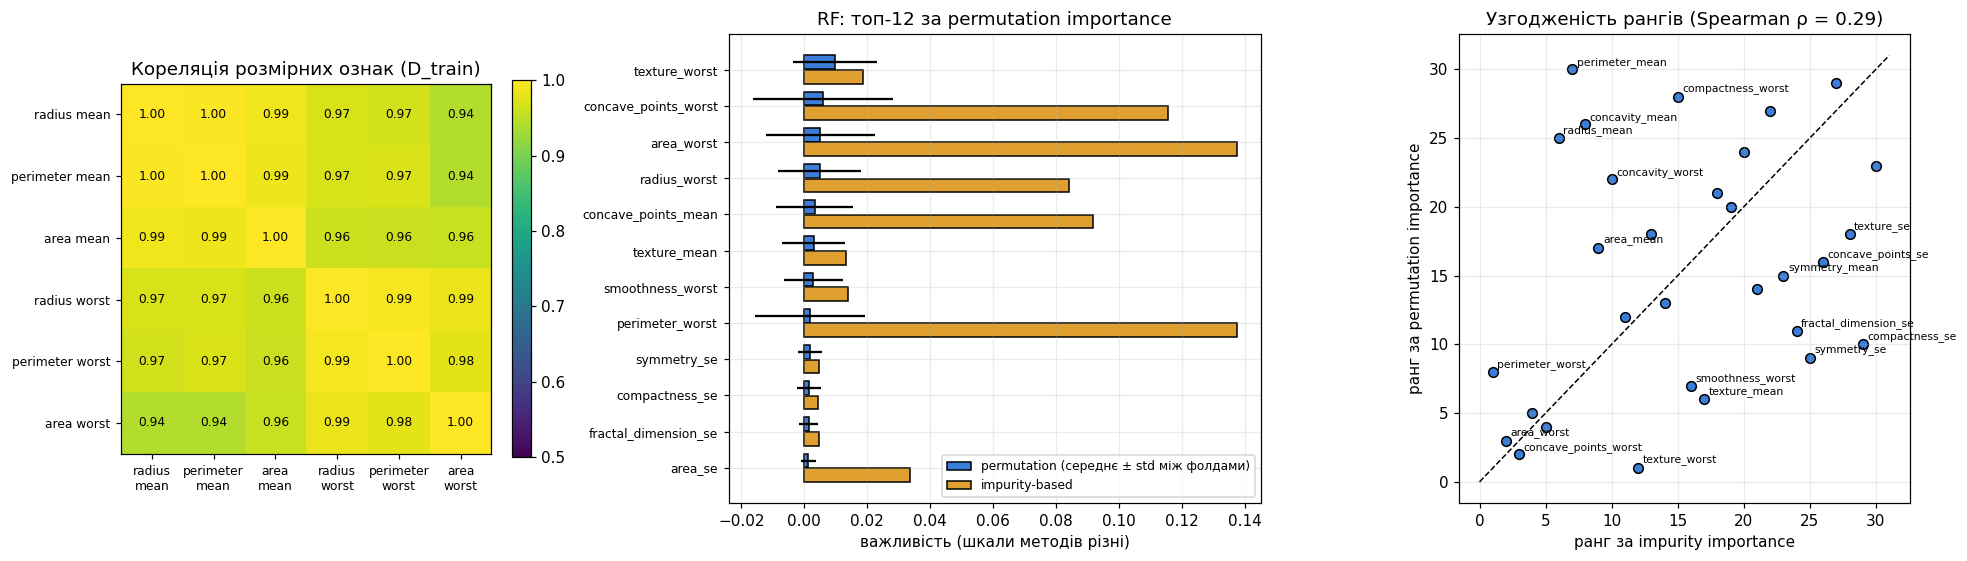

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2), gridspec_kw={"width_ratios": [1, 1.3, 1.1]})
ax = axes[0]
Cm = Csize.to_numpy()
im = ax.imshow(Cm, vmin=0.5, vmax=1, cmap="viridis")
ax.set_xticks(range(6), [c.replace("_", "\n") for c in size_core], fontsize=8)
ax.set_yticks(range(6), [c.replace("_", " ") for c in size_core], fontsize=8)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{Cm[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if Cm[i, j] < 0.8 else "black")
ax.grid(False)
ax.set_title("Кореляція розмірних ознак (D_train)")
fig.colorbar(im, ax=ax, fraction=0.046)

top = imp_rf_tbl.head(12).iloc[::-1]
ax = axes[1]
yy = np.arange(len(top))
ax.barh(yy + 0.2, top["pi_mean"], height=0.38, xerr=top["pi_fold_std"], color="#3b7dd8", edgecolor="black",
        label="permutation (середнє ± std між фолдами)")
ax.barh(yy - 0.2, top["impurity"], height=0.38, color="#e0a030", edgecolor="black", label="impurity-based")
ax.set_yticks(yy, top.index, fontsize=8)
ax.set_xlabel("важливість (шкали методів різні)")
ax.set_title("RF: топ-12 за permutation importance")
ax.legend(fontsize=8, loc="lower right")

ax = axes[2]
ax.scatter(imp_rf_tbl["impurity_rank"], imp_rf_tbl["pi_rank"], color="#3b7dd8", edgecolor="black", s=40)
lim = len(FEATURES) + 1
ax.plot([0, lim], [0, lim], "k--", linewidth=1)
for f in imp_rf_tbl.index:
    r_ = imp_rf_tbl.loc[f]
    if abs(r_["rank_diff"]) >= 8 or r_["pi_rank"] <= 3 or r_["impurity_rank"] <= 3:
        ax.annotate(f, (r_["impurity_rank"], r_["pi_rank"]), fontsize=7, xytext=(3, 3), textcoords="offset points")
ax.set_xlabel("ранг за impurity importance")
ax.set_ylabel("ранг за permutation importance")
ax.set_title(f"Узгодженість рангів (Spearman ρ = {rho_rf:.2f})")
fig.tight_layout()
fig.savefig(FIG / "06_feature_importance_rf.png", bbox_inches="tight")
plt.show()

**Рис. 6** (`figures/06_feature_importance_rf.png`). Ліворуч — кореляції розмірних ознак ($\ge 0.94$, медіана 0.97) як причина компенсації. Посередині — топ-12 за PI поруч з impurity importance (шкали різні, горизонтальні
«вуса» — std між folds: для більшості ознак вони перекривають нуль). Праворуч — діаграма розсіювання рангів: далеко від діагоналі лежать розмірні ознаки (високий ранг за impurity, низький за PI)
та ознаки текстури (навпаки).

In [23]:
# H5: для корельованих розмірних ознак ранги impurity та permutation суттєво відрізняються
size_tbl = imp_rf_tbl.loc[size_core, ["pi_mean", "pi_rank", "impurity", "impurity_rank", "rank_diff"]]
print(size_tbl.round(4).to_string())
mean_abs_diff = size_tbl["rank_diff"].abs().mean()
rest_diff = imp_rf_tbl.drop(index=size_core)["rank_diff"].abs().mean()
print(f"\nСума impurity-важливостей розмірних ознак = {imp_rf_tbl.loc[size_core, 'impurity'].sum():.3f}; "
      f"частка в сумі додатних PI = {imp_rf_tbl.loc[size_core, 'pi_mean'].clip(lower=0).sum() / imp_rf_tbl['pi_mean'].clip(lower=0).sum():.3f}")
print(f"Середній |Δранг| для 6 розмірних ознак = {mean_abs_diff:.2f}; для решти 24 ознак = {rest_diff:.2f}")
n_big = int((size_tbl["rank_diff"].abs() >= 5).sum())
H5_ok = bool(n_big >= 3 and mean_abs_diff > rest_diff)
print(f"Розмірних ознак з |Δранг| ≥ 5: {n_big} з 6")
print(f"H5 (≥ 3 з 6 розмірних ознак мають |Δранг| ≥ 5 і середній |Δранг| більший, ніж у решти) -> "
      f"{'ПІДТВЕРДЖЕНО' if H5_ok else 'НЕ ПІДТВЕРДЖЕНО'}")

                 pi_mean  pi_rank  impurity  impurity_rank  rank_diff
radius_mean      -0.0013       25    0.0627              6        -19
perimeter_mean   -0.0023       30    0.0497              7        -23
area_mean         0.0000       17    0.0405              9         -8
radius_worst      0.0049        4    0.0841              5          1
perimeter_worst   0.0019        8    0.1373              1         -7
area_worst        0.0050        3    0.1373              2         -1

Сума impurity-важливостей розмірних ознак = 0.512; частка в сумі додатних PI = 0.266
Середній |Δранг| для 6 розмірних ознак = 9.83; для решти 24 ознак = 7.83
Розмірних ознак з |Δранг| ≥ 5: 4 з 6
H5 (≥ 3 з 6 розмірних ознак мають |Δранг| ≥ 5 і середній |Δранг| більший, ніж у решти) -> ПІДТВЕРДЖЕНО


**H5 — ПІДТВЕРДЖЕНО за правилом**: 4 з 6 розмірних ознак мають $|\Delta\text{ранг}| \ge 5$ (`radius_mean` −19, `perimeter_mean` −23, `area_mean` −8, `perimeter_worst` −7), середній $|\Delta\text{ранг}|$ = 9.8 проти 7.8 для решти.
**Застереження:** запас за середнім $|\Delta|$ невеликий, бо серед «решти» багато ознак із шумовими рангами PI; переконливіше за ранги — групова PI (0.261 проти 0.008) з таблиці вище.

## 9. Поведінка моделі та часткові залежності (Stage 9)

PDP (`PartialDependenceDisplay`, `kind="average"`) для ансамблю-кандидата (навчений лише на $D_{train}$; фінальне навчання
в розділі 12 — той самий детермінований набір параметрів). Для бінарної задачі PDP будується для класу `classes_[1]` = **malignant**.
Ознаки обрано серед топ-5 за PI та змістовно інтерпретовних: **`concave_points_worst`** (кількість/виразність увігнутих ділянок контуру ядра —
ознака форми) і **`radius_worst`** (радіус найбільших ядер — ознака розміру; саме вона — корінь контрольованого дерева). Для порівняння на тих самих осях показано PDP контрольованого
дерева (східчаста функція) та пороги його розбиттів. Внизу кожного графіка — «rug» усіх навчальних значень (сірі риски) і децилі (чорні риски sklearn).

In [24]:
ens_pipe = FACTORIES[ENS]().fit(X_train, y_train)     # ансамбль-кандидат (за правилом протоколу), лише D_train
if ENS == "random_forest":
    ens_pipe.set_params(model__n_jobs=1)              # PDP = багато коротких predict; потоки лише гальмують
top5_pi = list(imp_rf_tbl.index[:5])
print("Ансамбль для PDP:", LABELS[ENS], "| топ-5 за PI (RF):", top5_pi)
PDP_FEATURES = ["concave_points_worst", "radius_worst"]
assert all(f in top5_pi for f in PDP_FEATURES), "обрані ознаки мають входити до топ-5 за PI"
tree_thr = {}
for f_idx, thr_ in zip(ctrl_tree.tree_.feature, ctrl_tree.tree_.threshold):
    if f_idx >= 0:
        tree_thr.setdefault(FEATURES[f_idx], []).append(float(thr_))
print("Пороги контрольованого дерева за ознаками:", {k: [round(v, 4) for v in vs] for k, vs in tree_thr.items()})
print(f"Кореляція між обраними ознаками (D_train): {X_train[PDP_FEATURES[0]].corr(X_train[PDP_FEATURES[1]]):.3f}")
for f in PDP_FEATURES:
    print(f"Ознаки з |ρ| ≥ 0.9 до {f}:", [g for g in FEATURES if g != f and abs(corr_train.loc[f, g]) >= 0.9])

Ансамбль для PDP: Random Forest | топ-5 за PI (RF): ['texture_worst', 'concave_points_worst', 'area_worst', 'radius_worst', 'concave_points_mean']
Пороги контрольованого дерева за ознаками: {'radius_worst': [16.795], 'concave_points_worst': [0.1359], 'area_se': [35.74], 'texture_mean': [19.71, 16.535], 'texture_se': [1.673]}
Кореляція між обраними ознаками (D_train): 0.781
Ознаки з |ρ| ≥ 0.9 до concave_points_worst: ['concave_points_mean']
Ознаки з |ρ| ≥ 0.9 до radius_worst: ['radius_mean', 'perimeter_mean', 'area_mean', 'perimeter_worst', 'area_worst']


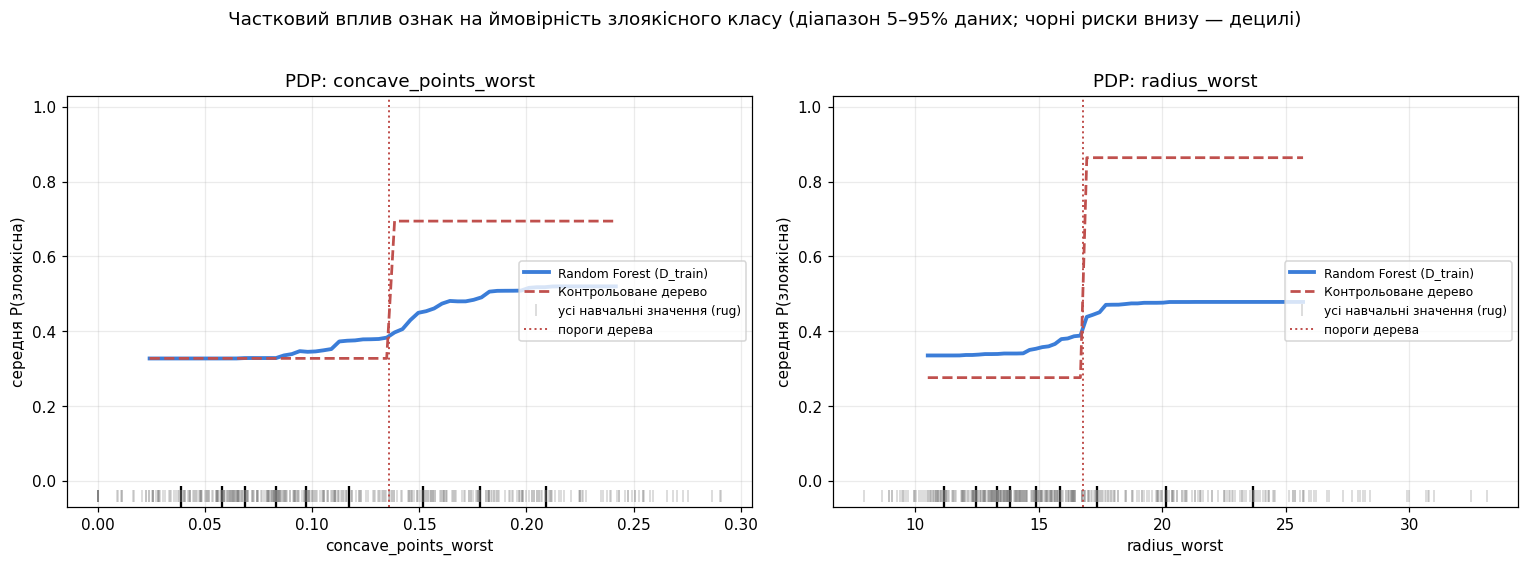


concave_points_worst: PDP від 0.327 до 0.520; підйом з 10% до 90% діапазону між 0.094 та 0.183; квантилі {0.05: 0.025, 0.25: 0.063, 0.5: 0.097, 0.75: 0.162, 0.95: 0.24}
   нижні 10% значень: n=46, частка злоякісних у D_train = 0.02
   верхні 10% значень: n=46, частка злоякісних у D_train = 1.00
   зона переходу [0.094; 0.183]: n=148 (32.5% об'єктів), частка злоякісних = 0.53

radius_worst: PDP від 0.335 до 0.478; підйом з 10% до 90% діапазону між 14.635 та 17.722; квантилі {0.05: 10.552, 0.25: 13.01, 0.5: 14.91, 0.75: 18.55, 0.95: 25.686}
   нижні 10% значень: n=47, частка злоякісних у D_train = 0.00
   верхні 10% значень: n=46, частка злоякісних у D_train = 1.00
   зона переходу [14.635; 17.722]: n=111 (24.4% об'єктів), частка злоякісних = 0.37


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pdp_tables = []
for ax, feat in zip(axes, PDP_FEATURES):
    d_ens = PartialDependenceDisplay.from_estimator(
        ens_pipe, X_train, [feat], kind="average", ax=ax, grid_resolution=60, percentiles=(0.05, 0.95),
        line_kw={"color": COLORS[ENS], "linewidth": 2.5, "label": f"{LABELS[ENS]} (D_train)"})
    ax = d_ens.axes_[0, 0]      # Display створює власну вкладену вісь усередині переданої
    pd_tree = partial_dependence(ctrl_pipe, X_train, [feat], kind="average", grid_resolution=60, percentiles=(0.05, 0.95))
    ax.plot(pd_tree["grid_values"][0], pd_tree["average"][0], color=COLORS["tree_controlled"], linewidth=1.8,
            linestyle="--", label="Контрольоване дерево")
    for nm, grid_v, avg_v in [(ENS, d_ens.pd_results[0]["grid_values"][0], d_ens.pd_results[0]["average"][0]),
                              ("tree_controlled", pd_tree["grid_values"][0], pd_tree["average"][0])]:
        pdp_tables.append(pd.DataFrame({"feature": feat, "model": nm, "grid_value": np.asarray(grid_v),
                                        "avg_p_malignant": np.asarray(avg_v).ravel()}))
    ymin = -0.04
    ax.plot(X_train[feat], np.full(len(X_train), ymin), "|", color="gray", alpha=0.35, markersize=8, label="усі навчальні значення (rug)")
    for j, t_ in enumerate(tree_thr.get(feat, [])):
        ax.axvline(t_, color=COLORS["tree_controlled"], linestyle=":", linewidth=1.3,
                   label="пороги дерева" if j == 0 else None)
    ax.set_ylim(-0.07, 1.03)
    ax.set_xlabel(feat)
    ax.set_ylabel("середня P(злоякісна)")
    ax.set_title(f"PDP: {feat}")
    ax.legend(fontsize=8, loc="center right")
fig.suptitle("Частковий вплив ознак на ймовірність злоякісного класу (діапазон 5–95% даних; чорні риски внизу — децилі)", y=1.02)
fig.tight_layout()
fig.savefig(FIG / "07_partial_dependence.png", bbox_inches="tight")
plt.show()
pdp_df = pd.concat(pdp_tables, ignore_index=True)
pdp_df.to_csv(RES / "pdp_values.csv", index=False)

for feat in PDP_FEATURES:
    sub = pdp_df[(pdp_df["feature"] == feat) & (pdp_df["model"] == ENS)]
    lo, hi = sub["avg_p_malignant"].min(), sub["avg_p_malignant"].max()
    lvl10, lvl90 = lo + 0.1 * (hi - lo), lo + 0.9 * (hi - lo)       # 10% і 90% діапазону PDP
    x10 = sub.loc[sub["avg_p_malignant"] >= lvl10, "grid_value"].min()
    x90 = sub.loc[sub["avg_p_malignant"] >= lvl90, "grid_value"].min()
    q = X_train[feat].quantile([0.05, 0.25, 0.5, 0.75, 0.95]).round(3).to_dict()
    print(f"\n{feat}: PDP від {lo:.3f} до {hi:.3f}; підйом з 10% до 90% діапазону між {x10:.3f} та {x90:.3f}; квантилі {q}")
    for lab, mask in [("нижні 10% значень", X_train[feat] <= X_train[feat].quantile(0.1)),
                      ("верхні 10% значень", X_train[feat] >= X_train[feat].quantile(0.9))]:
        print(f"   {lab}: n={int(mask.sum())}, частка злоякісних у D_train = {y_train[mask].mean():.2f}")
    mid_mask = (X_train[feat] >= x10) & (X_train[feat] <= x90)
    print(f"   зона переходу [{x10:.3f}; {x90:.3f}]: n={int(mid_mask.sum())} ({mid_mask.mean() * 100:.1f}% об'єктів), "
          f"частка злоякісних = {y_train[mid_mask].mean():.2f}")

**Рис. 7** (`figures/07_partial_dependence.png`, значення — `results/pdp_values.csv`). Суцільна синя лінія — PDP Random Forest, червона пунктирна — PDP контрольованого дерева, пунктирні вертикалі — пороги дерева; сірі риски — усі
навчальні значення, чорні риски внизу — децилі.

**`concave_points_worst`.** PDP RF плоский (≈ 0.33) до ≈ 0.08, потім піднімається приблизно від 0.09 до 0.18 (інтервал, де PDP проходить 10 % → 90 % свого діапазону; у ньому 148 об'єктів, 32.5 % даних,
53 % злоякісних; найкрутіше біля 0.13–0.15) і виходить на плато ≈ 0.52 після ≈ 0.21. **Поріг дерева 0.136 лежить усередині зони підйому** — форма узгоджується з правилом дерева, але ансамбль
має плавну, а не східчасту залежність.

**`radius_worst`.** PDP плоский (≈ 0.34) до ≈ 13, підйом від ≈ 14.6 до ≈ 17.7 (111 об'єктів, 24 % даних, 37 % злоякісних), найкрутіше біля 16–17, плато ≈ 0.48 після 18. **Поріг кореня дерева 16.795 збігається з найкрутішою ділянкою.**

**Де висновок ненадійний.** Верхні 10 % значень (> ≈ 20 для `radius_worst`, > ≈ 0.21 для `concave_points_worst`) розтягнені на широкий діапазон з рідкісними точками — «плато» там описує мало об'єктів
(і всі вони злоякісні); показано лише діапазон 5–95 %. Також у зоні переходу даних суттєво більше, ніж на краях, але саме там модель найменш певна.

**Обмеження через кореляції.** Амплітуда PDP дуже мала (0.33 → 0.52 та 0.34 → 0.48), хоч у нижніх 10 % значень обох ознак злоякісних 0–2 %, а у верхніх 10 % — 100 %. PDP змінює **одну** ознаку при незмінних інших і
усереднює по комбінаціях: `radius_worst` корелює ($|\rho| \ge 0.9$) з п'ятьма розмірними ознаками, `concave_points_worst` — з `concave_points_mean`, а між самими обраними ознаками $\rho = 0.78$. Штучне «зменшення» радіуса при
незмінних периметрі й площі — комбінація, якої в даних немає; ліс спирається на всі ці ознаки одночасно, тому окрема ознака рухає прогноз мало. Для порівняння, PDP дерева — східчаста функція з великою амплітудою (0.33 → 0.69 для `concave_points_worst` і 0.28 → 0.86 для `radius_worst`): дерево використовує лише 5 ознак і приписує весь ефект одному порогу, тоді як ліс розподіляє його між багатьма корельованими ознаками. Це опис **відгуку моделі на ізольовану зміну ознаки в межах наявних даних**,
а не розподілу класів за ознакою й не причинний ефект.

## 10. Розбіжності прогнозів (Stage 10)

OOF-прогнози контрольованого дерева (фіксовані параметри), RF і HistGB на **одному** `StratifiedKFold(5, shuffle=True, random_state=42)`
по $D_{train}$. Категорії:

* **A** — дерево помилилося, обидва ансамблі правильні;
* **B** — дерево правильне, хоча б один ансамбль помилився;
* **C** — ансамблі розійшлися між собою;
* **D** — усі три моделі помилилися.

Для детального аналізу береться 10 об'єктів. Метрики пояснення: відстань до найближчого порога на шляху fold-дерева (в одиницях std
ознаки); «рідкісність» — перцентиль середньої відстані до 5 найближчих сусідів (у стандартизованому просторі, лише для аналізу);
частка злоякісних серед 10 найближчих навчальних сусідів; наявність пропусків.

In [26]:
shared_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
M3 = {"tree": "tree_controlled", "rf": "random_forest", "hgb": "hist_gb"}
oof_pred = {k: np.zeros(len(X_train), dtype=int) for k in M3}
oof_proba = {k: np.zeros(len(X_train)) for k in M3}
fold_of = np.zeros(len(X_train), dtype=int)
fold_trees = {}
for k, (tr_idx, va_idx) in enumerate(shared_cv.split(X_train, y_train)):
    fold_of[va_idx] = k
    for key, name in M3.items():
        est = FACTORIES[name]().fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        oof_pred[key][va_idx] = est.predict(X_train.iloc[va_idx])
        oof_proba[key][va_idx] = est.predict_proba(X_train.iloc[va_idx])[:, 1]
        if key == "tree":
            fold_trees[k] = est
yv = y_train.values
for key in M3:
    print(f"{key:5s}: OOF macro F1 = {f1_score(yv, oof_pred[key], average='macro'):.4f}, "
          f"помилок = {int((oof_pred[key] != yv).sum())}")

keys = list(M3)
dis_mat = pd.DataFrame({b: {a: (oof_pred[a] != oof_pred[b]).mean() for a in keys} for b in keys})
print("\nЧастка об'єктів, де прогнози двох моделей не збігаються:")
print(dis_mat.round(4).to_string())

wrong = {k: oof_pred[k] != yv for k in keys}
cat_A = wrong["tree"] & ~wrong["rf"] & ~wrong["hgb"]                 # дерево помилилось, обидва ансамблі вірні
cat_B = ~wrong["tree"] & (wrong["rf"] | wrong["hgb"])                # дерево вірне, ≥1 ансамбль помилився
cat_C = oof_pred["rf"] != oof_pred["hgb"]                            # ансамблі розійшлися
cat_D = wrong["tree"] & wrong["rf"] & wrong["hgb"]                   # усі помилились
all_same = (oof_pred["tree"] == oof_pred["rf"]) & (oof_pred["rf"] == oof_pred["hgb"])
print(f"\nA (дерево ✗, обидва ансамблі ✓): {int(cat_A.sum())}")
print(f"B (дерево ✓, хоча б один ансамбль ✗): {int(cat_B.sum())}")
print(f"C (RF ≠ HGB): {int(cat_C.sum())}")
print(f"D (усі три ✗): {int(cat_D.sum())}")
print(f"Усі три прогнози однакові: {int(all_same.sum())} з {len(yv)}; перетин B∩C = {int((cat_B & cat_C).sum())}")

dis_tbl = pd.DataFrame({
    "index": X_train.index, "y_true": yv, "fold": fold_of,
    "pred_tree": oof_pred["tree"], "pred_rf": oof_pred["rf"], "pred_hgb": oof_pred["hgb"],
    "p_tree": oof_proba["tree"], "p_rf": oof_proba["rf"], "p_hgb": oof_proba["hgb"],
    "cat_A_tree_wrong_both_right": cat_A, "cat_B_tree_right_ens_wrong": cat_B,
    "cat_C_ensembles_disagree": cat_C, "cat_D_all_wrong": cat_D,
})
dis_tbl = dis_tbl[~all_same | cat_D].reset_index(drop=True)
dis_tbl.to_csv(RES / "model_disagreements.csv", index=False)
print(f"\nТаблиця розбіжностей збережена: {len(dis_tbl)} об'єктів (моделі не збігаються між собою або всі помилилися)")

tree : OOF macro F1 = 0.9257, помилок = 32
rf   : OOF macro F1 = 0.9601, помилок = 17
hgb  : OOF macro F1 = 0.9670, помилок = 14

Частка об'єктів, де прогнози двох моделей не збігаються:
        tree      rf     hgb
tree  0.0000  0.0374  0.0527
rf    0.0374  0.0000  0.0242
hgb   0.0527  0.0242  0.0000

A (дерево ✗, обидва ансамблі ✓): 15
B (дерево ✓, хоча б один ансамбль ✗): 4
C (RF ≠ HGB): 11
D (усі три ✗): 10
Усі три прогнози однакові: 429 з 455; перетин B∩C = 4

Таблиця розбіжностей збережена: 36 об'єктів (моделі не збігаються між собою або всі помилилися)


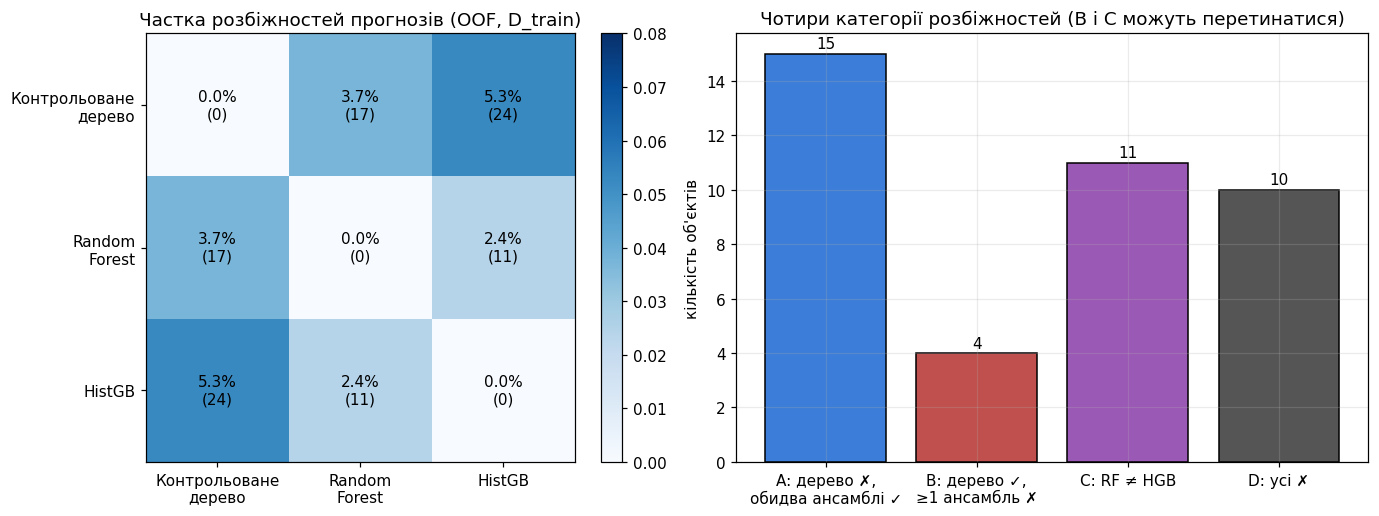

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), gridspec_kw={"width_ratios": [1, 1.2]})
ax = axes[0]
D = dis_mat.to_numpy()
im = ax.imshow(D, cmap="Blues", vmin=0, vmax=max(0.08, D.max()))
names3 = ["Контрольоване\nдерево", "Random\nForest", "HistGB"]
ax.set_xticks(range(3), names3)
ax.set_yticks(range(3), names3)
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{D[i, j] * 100:.1f}%\n({int(round(D[i, j] * len(yv)))})", ha="center", va="center", fontsize=10)
ax.grid(False)
ax.set_title("Частка розбіжностей прогнозів (OOF, D_train)")
fig.colorbar(im, ax=ax, fraction=0.046)

ax = axes[1]
cats = [("A: дерево ✗,\nобидва ансамблі ✓", cat_A), ("B: дерево ✓,\n≥1 ансамбль ✗", cat_B),
        ("C: RF ≠ HGB", cat_C), ("D: усі ✗", cat_D)]
vals = [int(c.sum()) for _, c in cats]
bars = ax.bar([n for n, _ in cats], vals, color=["#3b7dd8", "#c0504d", "#9b59b6", "#555555"], edgecolor="black")
for b_, v in zip(bars, vals):
    ax.text(b_.get_x() + b_.get_width() / 2, v + 0.2, str(v), ha="center")
ax.set_ylabel("кількість об'єктів")
ax.set_title("Чотири категорії розбіжностей (B і C можуть перетинатися)")
fig.tight_layout()
fig.savefig(FIG / "08_model_disagreement.png", bbox_inches="tight")
plt.show()

**Рис. 8** (`figures/08_model_disagreement.png`, таблиця — `results/model_disagreements.csv`, 36 об'єктів).

OOF macro F1 на одному 5-fold: дерево 0.926 (32 помилки), RF 0.960 (17), HGB 0.967 (14). Розбіжності: дерево–RF 3.7 %, дерево–HGB 5.3 %, **RF–HGB 2.4 %** — ансамблі схожі між собою значно більше, ніж на дерево.
Усі три збігаються на 429 з 455 об'єктів.

* **A (дерево ✗, обидва ансамблі ✓): 15**; **B (дерево ✓, хоч один ансамбль ✗): 4**; **C (RF ≠ HGB): 11**; **D (усі ✗): 10** (категорії B і C перетинаються: B ⊂ C у цьому прогоні).
* Ансамблі виправляють помилки дерева майже в 4 рази частіше, ніж псують його правильні прогнози. 10 об'єктів D (2.2 %) — помилки, спільні для всіх моделей, тобто зона, де проблема не в типі моделі.

In [28]:
# --- Допоміжні характеристики для детального розгляду -------------------------------------------
Zs = StandardScaler().fit_transform(X_train)               # лише для вимірювання відстаней (не для моделей)
dist_all, nbr_all = NearestNeighbors(n_neighbors=11).fit(Zs).kneighbors(Zs)
knn5_pct = pd.Series(dist_all[:, 1:6].mean(axis=1)).rank(pct=True).to_numpy()   # перцентиль «рідкісності»
knn10_mal = yv[nbr_all[:, 1:11]].mean(axis=1)                                   # частка злоякісних серед 10 сусідів
feat_std = X_train.std()


def tree_margin(i):
    """Мінімальна відстань (в одиницях std ознаки) до порога на шляху fold-дерева, яке прогнозувало об'єкт i."""
    est = fold_trees[fold_of[i]]
    t_ = est.named_steps["model"]
    z_ = est[:-1].transform(X_train.iloc[[i]])
    nodes = t_.decision_path(z_).indices
    best = (np.inf, None, None, None)
    for nid in nodes:
        if t_.tree_.children_left[nid] == -1:
            continue
        j = t_.tree_.feature[nid]
        mg = abs(z_[0, j] - t_.tree_.threshold[nid]) / feat_std.iloc[j]
        if mg < best[0]:
            best = (mg, FEATURES[j], t_.tree_.threshold[nid], z_[0, j])
    leaf = int(nodes[-1])
    return best + (int(t_.tree_.n_node_samples[leaf]),)


# --- Відбір: у кожній категорії беремо об'єкти з найбільшим розривом P(tree) − P(RF) ----------
spread = np.abs(oof_proba["tree"] - oof_proba["rf"]) + 0.001 * np.abs(oof_proba["rf"] - oof_proba["hgb"])
only_C = cat_C & ~cat_A & ~cat_B & ~cat_D
picked = []
for tag, mask, n_take in [("D", cat_D, 3), ("A", cat_A, 3), ("B", cat_B, 2), ("C", only_C, 2)]:
    cand = [i for i in np.argsort(-spread) if mask[i] and i not in [p for p, _ in picked]]
    picked += [(i, tag) for i in cand[:n_take]]

recs = []
for i, tag in picked:
    mg, mf, mthr, mval, leaf_n = tree_margin(i)
    recs.append({
        "index": X_train.index[i], "кат.": tag, "y": yv[i],
        "tree/rf/hgb": f"{oof_pred['tree'][i]}/{oof_pred['rf'][i]}/{oof_pred['hgb'][i]}",
        "p_tree": oof_proba["tree"][i], "p_rf": oof_proba["rf"][i], "p_hgb": oof_proba["hgb"][i],
        "лист n": leaf_n, "найближчий поріг": mf, "значення": mval, "поріг": mthr, "відст., σ": mg,
        "kNN5 перцентиль": knn5_pct[i], "kNN10 частка M": knn10_mal[i],
    })
detail = pd.DataFrame(recs)
detail.to_csv(RES / "detailed_objects.csv", index=False)
print(detail.round(3).to_string(index=False))
print(f"\nДовідково (усі об'єкти D_train): медіана відстані до найближчого порога на шляху (σ) — "
      f"{np.median([tree_margin(i)[0] for i in range(len(X_train))]):.3f}")
print(f"Пропусків у ознаках цих об'єктів: {int(X_train.iloc[[i for i, _ in picked]].isna().sum().sum())}")

 index кат.  y tree/rf/hgb  p_tree  p_rf  p_hgb  лист n     найближчий поріг  значення   поріг  відст., σ  kNN5 перцентиль  kNN10 частка M
    38    D  1       0/0/0   0.005 0.500  0.441     183      perimeter_worst    95.540 106.100      0.318            0.943             0.2
   536    D  1       0/0/0   0.009 0.407  0.102     211      perimeter_worst   104.300 112.800      0.256            0.512             0.6
   413    D  0       1/1/1   0.812 0.523  0.786      16      perimeter_worst   110.200 106.100      0.124            0.549             0.5
   147    A  0       1/0/0   0.812 0.250  0.143      16      perimeter_worst   107.100 106.100      0.030            0.760             0.0
   376    A  0       1/0/0   0.688 0.170  0.039      16 concave_points_worst     0.146   0.146      0.013            0.921             0.2
    36    A  1       0/1/1   0.217 0.733  0.955      23 concave_points_worst     0.145   0.156      0.174            0.470             0.8
   514    B  1       1/1/0 


Довідково (усі об'єкти D_train): медіана відстані до найближчого порога на шляху (σ) — 0.350
Пропусків у ознаках цих об'єктів: 0


**Детальний розгляд 10 об'єктів** (`results/detailed_objects.csv`; відстань до порога — у std ознаки, по шляху fold-дерева, яке передбачало цей об'єкт; медіана за всіма об'єктами $D_{train}$ — 0.35σ):

| Кат. | Об'єкт (істина) | Що видно |
|---|---|---|
| D | 38 (M) | усі помилилися; ймовірності ансамблів 0.50 / 0.44 — «монетка»; дерево потрапило у великий доброякісний листок (183), `perimeter_worst` 95.5 лише 0.32σ нижче порога; об'єкт **рідкісний** (kNN5 — 94-й перцентиль), серед 10 сусідів злоякісних 20 % — атиповий злоякісний, схожий на доброякісні |
| D | 536 (M) | дерево 0.009, RF 0.41, HGB 0.10; листок 211, поріг 0.26σ; у сусідстві 60 % злоякісних — змішана зона, RF майже на межі |
| D | 413 (B) | усі кажуть «злоякісна» (0.81 / 0.52 / 0.79); листок із 16 об'єктів, значення лише 0.12σ вище порога; сусіди 50 : 50 |
| A | 147 (B) | дерево помилилося (0.81, листок 16), `perimeter_worst` 107.1 лише **0.03σ** вище порога 106.1; сусіди 0 % злоякісних; ансамблі правильні (0.25 / 0.14) |
| A | 376 (B) | `concave_points_worst` 0.146 — практично **на порозі** (0.013σ), листок 16, об'єкт ізольований (kNN5 92-й перцентиль); дерево 0.69, RF 0.17, HGB 0.04 |
| A | 36 (M) | дерево 0 (листок 23), значення 0.145 лише 0.17σ нижче порога 0.156; 80 % сусідів злоякісні; ансамблі 0.73 / 0.96 |
| B | 514 (M) | дерево 1.0 (листок 90, 0.16σ від порога), RF 0.68 правильно, HGB 0.39 помилився; зона щільна (kNN5 24-й перцентиль), сусіди 40 % злоякісних — змішане оточення |
| B | 484 (B) | дерево 0.37 (✓), RF 0.62 (✗, майже на межі), HGB 0.16; 0.19σ від порога, сусіди 20 % злоякісних |
| C | 193 (M) | дерево 0.01 (листок 203), RF 0.45 — обидва помилилися, HGB 0.76 правильно; поріг 0.02σ; **усі 10 сусідів злоякісні** — тут правий метод, що точніше використовує локальну структуру |
| C | 396 (B) | дерево 0.64 (✗), RF 0.27 (✓), HGB 0.73 (✗); 0.14σ від порога, сусіди 30 % злоякісних |

**Закономірності.** (1) Усі 10 об'єктів лежать ближче до порога, ніж медіана (≤ 0.32σ проти 0.35σ), 8 з 10 — ближче 0.2σ: помилки дерева в категорії A — це об'єкти біля порога в **малих листках (16–23 об'єкти) зі змішаним складом**,
а ансамбль усереднює багато трохи зсунутих порогів і «розмиває» таку межу. (2) Для об'єктів D RF дає ймовірності 0.41–0.52 — це не впевнені помилки, а справжні межові випадки (HGB для 536 — 0.10, для 413 — 0.79, тобто він упевненіший, але теж помиляється). (3) «Рідкісні комбінації» пояснюють
лише частину: кількість об'єктів з kNN5 > 90-го перцентиля — 2 (38, 376). (4) **Пропусків у даних немає**, тому вони не можуть пояснити розбіжності. (5) Пороги й навіть кореневі ознаки fold-дерев відрізняються
(у цих folds корінь — `perimeter_worst`, а не `radius_worst`), що узгоджується з H4.

## 11. Інженерні характеристики (Stage 11)

Три моделі — на одному комп'ютері, повний $D_{train}$. Час — **медіана** 7 запусків `fit` та 15 запусків `predict` для 1000 об'єктів
(вибірка з $D_{train}$ з поверненням, `random_state=42`) після одного прогрівального запуску. Розмір — `len(pickle.dumps(pipeline))`.

**Чесність порівняння потоків.** RF розпаралелюється через `n_jobs` (потоки joblib), HistGradientBoosting — через OpenMP (параметра `n_jobs` немає),
дерево однопотокове. На такій малій вибірці (455 об'єктів) накладні витрати на потоки можуть переважати користь від паралелізму, тому **основна таблиця вимірюється в однопотоковому режимі для всіх трьох моделей**:
`threadpoolctl.threadpool_limits(limits=1)` (обмежує OpenMP/BLAS) і `n_jobs=1` для RF. Додатково, як **діагностика**, наведено RF з `n_jobs=-1` та HGB з усіма OpenMP-потоками (`threads = all`),
щоб було видно ефект накладних витрат. Числа характеризують конкретне середовище й придатні лише для порівняння моделей між собою в межах цього експерименту.

In [29]:
def median_time(fn, n_runs):
    ts = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        fn()
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts))


def total_nodes(est):
    m_ = est.named_steps["model"]
    if hasattr(m_, "tree_"):
        return int(m_.tree_.node_count), 1
    if hasattr(m_, "estimators_"):
        return int(sum(t.tree_.node_count for t in m_.estimators_)), len(m_.estimators_)
    return int(sum(len(p.nodes) for it in m_._predictors for p in it)), int(m_.n_iter_)


rng_t = np.random.default_rng(RANDOM_STATE)
X_1000 = X_train.iloc[rng_t.integers(0, len(X_train), 1000)]       # 1000 об'єктів (вибірка з D_train з поверненням)
N_FIT, N_PRED = 7, 15
expl = {"tree_controlled": "повний шлях правил (decision_path)",
        "random_forest": "частка голосів дерев; ICE; permutation (глобально)",
        "hist_gb": "ICE/PDP; вбудованого шляху немає"}


def build(name, single_thread):
    est = FACTORIES[name]()
    if single_thread and name == "random_forest":
        est.set_params(model__n_jobs=1)          # RF розпаралелюється через n_jobs (потоки joblib)
    return est


def measure(name, single_thread):
    # HistGradientBoosting розпаралелюється через OpenMP, а не n_jobs, тому для чесного порівняння
    # однопотокового режиму обмежуємо пули потоків бібліотек через threadpoolctl.
    with (threadpool_limits(limits=1) if single_thread else contextlib.nullcontext()):
        build(name, single_thread).fit(X_train, y_train)                          # прогрівальний запуск
        fit_t = median_time(lambda: build(name, single_thread).fit(X_train, y_train), N_FIT)
        est = build(name, single_thread).fit(X_train, y_train)
        est.predict(X_1000)                                                       # прогрів predict
        pred_t = median_time(lambda: est.predict(X_1000), N_PRED)
    n_nodes, n_units = total_nodes(est)
    return {"model": name, "threads": "1" if single_thread else "all",
            "fit_s (median)": fit_t, "predict_1000_ms (median)": pred_t * 1000,
            "pickle_KB": len(pickle.dumps(est)) / 1024, "trees/iterations": n_units,
            "total_nodes": n_nodes, "local explanation": expl[name]}


# Основна таблиця: усі три моделі в однопотоковому режимі (threadpool_limits(1) + n_jobs=1 для RF)
eng_rows = [measure(name, True) for name in ["tree_controlled", "random_forest", "hist_gb"]]
# Діагностика: ті ж моделі без обмеження потоків (RF з n_jobs=-1, HGB з усіма OpenMP-потоками)
eng_rows += [measure(name, False) for name in ["random_forest", "hist_gb"]]
eng_all = pd.DataFrame(eng_rows)
eng_all.to_csv(RES / "engineering_metrics.csv", index=False)
eng_df = eng_all[eng_all["threads"] == "1"].set_index("model")          # основна таблиця (далі в рішенні)
print("ОСНОВНА ТАБЛИЦЯ (1 потік) та діагностичні рядки (threads = all):")
print(eng_all.round(3).to_string(index=False))
print(f"Відношення до дерева (1 потік): RF fit x{eng_df.loc['random_forest', 'fit_s (median)'] / eng_df.loc['tree_controlled', 'fit_s (median)']:.0f}, "
      f"predict x{eng_df.loc['random_forest', 'predict_1000_ms (median)'] / eng_df.loc['tree_controlled', 'predict_1000_ms (median)']:.0f}; "
      f"HGB fit x{eng_df.loc['hist_gb', 'fit_s (median)'] / eng_df.loc['tree_controlled', 'fit_s (median)']:.0f}, "
      f"predict x{eng_df.loc['hist_gb', 'predict_1000_ms (median)'] / eng_df.loc['tree_controlled', 'predict_1000_ms (median)']:.0f}")

env = {
    "python": platform.python_version(), "scikit-learn": sklearn.__version__, "numpy": np.__version__,
    "pandas": pd.__version__, "matplotlib": matplotlib.__version__, "joblib": joblib.__version__,
    "os": platform.platform(), "processor": platform.processor(), "cpu_count": os.cpu_count(),
}
(RES / "environment.json").write_text(json.dumps(env, ensure_ascii=False, indent=2), encoding="utf-8")
print("\n" + json.dumps(env, ensure_ascii=False, indent=2))

ОСНОВНА ТАБЛИЦЯ (1 потік) та діагностичні рядки (threads = all):
          model threads  fit_s (median)  predict_1000_ms (median)  pickle_KB  trees/iterations  total_nodes                                  local explanation
tree_controlled       1           0.006                     1.289      3.281                 1           13                 повний шлях правил (decision_path)
  random_forest       1           0.569                    35.809    926.037               300        10680 частка голосів дерев; ICE; permutation (глобально)
        hist_gb       1           0.242                    17.500    247.199               200         2886                   ICE/PDP; вбудованого шляху немає
  random_forest     all           0.636                   103.456    926.040               300        10680 частка голосів дерев; ICE; permutation (глобально)
        hist_gb     all           0.211                     8.798    247.199               200         2886                   ICE/PDP; вбудо

**Таблиця** (`results/engineering_metrics.csv`, колонка `threads`: `1` — основна однопотокова, `all` — діагностична; середовище — `results/environment.json`). Абсолютні значення залежать від комп'ютера й запуску — важливі порядки величин; в однопотоковому режимі (діапазон за кількома запусками):

* **Контрольоване дерево:** навчання ≈ 6–7 мс, прогноз 1000 об'єктів ≈ 1.2–1.3 мс, файл ≈ 3.3 КБ, 1 дерево з 13 вузлів; локальне пояснення — повний шлях правил.
* **Random Forest:** навчання ≈ 0.5–0.55 с, прогноз 1000 об'єктів ≈ 30–34 мс, файл ≈ 926 КБ, 300 дерев, 10 680 вузлів; пояснення — частка голосів дерев, ICE, глобальна PI.
* **HistGradientBoosting:** навчання ≈ 0.23–0.24 с, прогноз ≈ 18–21 мс, файл ≈ 247 КБ, 200 ітерацій, 2 886 вузлів; пояснення — ICE/PDP, вбудованого шляху немає.

Відношення до дерева (однопотоково, див. друк під таблицею): RF навчається приблизно в 80–90 разів, а прогнозує приблизно в 25–30 разів повільніше; HGB — приблизно в 35–40 та 13–18 разів (при повторних запусках ці відношення коливаються на десятки відсотків, тому читати їх слід як порядок величини). Файл RF більший за файл дерева приблизно в 280 разів.

**Діагностичні рядки (`threads = all`) показують, що паралелізм на цих даних шкодить прогнозуванню:** RF з `n_jobs=-1` прогнозує 1000 об'єктів приблизно за 105–110 мс проти ≈ 30–34 мс в одному потоці (накладні витрати потоків), а навчання лише трохи повільніше (≈ 0.6–0.65 с проти ≈ 0.55 с);
HGB з усіма OpenMP-потоками прогнозує швидше (≈ 9 мс проти ≈ 18–21 мс), а навчання майже не змінюється (≈ 0.22 с проти ≈ 0.24 с). Тому цифри «RF у сотні разів повільніший за дерево» були б артефактом налаштування паралелізму, а не властивістю моделі.
Для офлайн-тріажу прогноз 1000 об'єктів займає соті частки секунди, а файл — менше мегабайта.

## 12. Вибір моделі та фінальна перевірка (Stage 12)

### 12.1. Таблиця рішення (до відкриття test set)

Усі числа — з розділів 5–11 (лише $D_{train}$).

In [30]:
F1m, F1s, F1min = summ["F1 mean"], summ["F1 std"], summ["F1 min"]
unst = stab_df["objects_unstable_gt25pct"]
dr = stab_df["mean_disagreement_rate"]
n_pi_stable = int((imp_rf_tbl["pi_top5_freq"] >= 3).sum())
n_imp_stable = int((imp_rf_tbl["imp_top5_freq"] >= 3).sum())
dec = pd.DataFrame([
    ["Середня якість (macro F1, зовн. фолди)", f"{F1m['tree_controlled']:.3f} (вкладена CV)",
     f"{F1m[ENS]:.3f} ({LABELS[ENS]})",
     f"Δ = {F1m[ENS] - F1m['tree_controlled']:+.3f} проти std дерева {F1s['tree_controlled']:.3f}"],
    ["Стійкість метрики між фолдами (std / min)", f"{F1s['tree_controlled']:.3f} / {F1min['tree_controlled']:.3f}",
     f"{F1s[ENS]:.3f} / {F1min[ENS]:.3f}", "std та найгірший фолд ансамблю кращі"],
    [f"Стійкість між розбиттями (діапазон q за {len(SEEDS)} seed)",
     f"{q_sum.loc['tree_controlled', 'range']:.4f}", f"{q_sum.loc[ENS, 'range']:.4f}",
     "вужчий діапазон у ансамблю" if q_sum.loc[ENS, "range"] < q_sum.loc["tree_controlled", "range"] else "співмірні"],
    ["Стійкість прогнозів (середня розбіжність; об'єктів > 25%)",
     f"{dr['tree_controlled'] * 100:.2f}%; {int(unst['tree_controlled'])}", f"{dr[ENS] * 100:.2f}%; {int(unst[ENS])}",
     f"відношення {dr['tree_controlled'] / max(dr[ENS], 1e-12):.1f}× (поріг H2: 3×)"],
    ["Час і розмір (fit; predict 1000; pickle)",
     f"{eng_df.loc['tree_controlled', 'fit_s (median)'] * 1000:.1f} мс; {eng_df.loc['tree_controlled', 'predict_1000_ms (median)']:.2f} мс; "
     f"{eng_df.loc['tree_controlled', 'pickle_KB']:.1f} КБ",
     f"{eng_df.loc[ENS, 'fit_s (median)'] * 1000:.0f} мс; {eng_df.loc[ENS, 'predict_1000_ms (median)']:.1f} мс; "
     f"{eng_df.loc[ENS, 'pickle_KB']:.0f} КБ",
     "ансамбль дорожчий, але в межах бюджету (predict 1000 < 1 с, файл < 50 МБ)"],
    ["Локальне пояснення", "повний шлях правил (Stage 3)", "голоси дерев, ICE; єдиного шляху немає",
     "перевага дерева; для ансамблю — лише опис поведінки"],
    ["Стабільність інтерпретації", f"корінь = {dom} лише у {dom_share * 100:.0f}% bootstrap-дерев",
     f"PI: у топ-5 ≥ 3 з 5 folds — {n_pi_stable} ознак; impurity: {n_imp_stable}",
     "ранги ансамблю нестабільні для PI, помірно стабільні для impurity; структура дерева нестабільна"],
], columns=["Критерій", "Контрольоване дерево", f"Ансамбль ({LABELS[ENS]})", "Вплив на рішення"])
print(dec.to_string(index=False))
dec.to_csv(RES / "decision_table.csv", index=False)

                                                 Критерій                                Контрольоване дерево                         Ансамбль (Random Forest)                                                                                Вплив на рішення
                   Середня якість (macro F1, зовн. фолди)                                 0.919 (вкладена CV)                            0.959 (Random Forest)                                                               Δ = +0.040 проти std дерева 0.033
                Стійкість метрики між фолдами (std / min)                                       0.033 / 0.855                                    0.017 / 0.930                                                            std та найгірший фолд ансамблю кращі
         Стійкість між розбиттями (діапазон q за 11 seed)                                              0.0297                                           0.0217                                                                      вужчий 

**Читання таблиці.** Ансамбль переважає за якістю (+0.040 macro F1, +5.6 п.п. recall), розкидом між folds (0.017 проти 0.033; найгірший fold 0.930 проти 0.855), діапазоном між розбиттями (0.022 проти 0.030) і стійкістю прогнозів (3.8× нижча розбіжність, 7 проти 33 нестійких об'єктів).
Дерево виграє за часом/розміром і єдиним **локальним поясненням** (повний шлях правил). За стабільністю інтерпретації виграшу немає в жодного: структура дерева змінюється між bootstrap-вибірками (корінь однаковий лише в 45 %),
а PI ансамблю шумна (лише `texture_worst` у топ-5 в ≥ 3 з 5 folds), хоча impurity-топ-5 ансамблю повторюється у всіх folds.

In [31]:
# Формальне застосування правила вибору, зафіксованого в протоколі до відкриття test set
crit_a = H1_ok                                                           # якість вища більш ніж на std дерева
crit_b = bool(H2_ok and m[ENS] >= m["tree_controlled"])                  # прогнози стійкіші ≥ 3×, якість не нижча
crit_c = bool(eng_df.loc[ENS, "predict_1000_ms (median)"] < 1000 and eng_df.loc[ENS, "pickle_KB"] < 50 * 1024)
use_ensemble = (crit_a or crit_b) and crit_c
print(f"(a) Δ macro F1 > std дерева -> {crit_a}")
print(f"(b) розбіжності прогнозів ≥ 3× нижчі і якість не нижча -> {crit_b}")
print(f"(c) інженерні витрати в межах бюджету -> {crit_c}")
FINAL_NAME = ENS if use_ensemble else "tree_controlled"
print(f"\nОбрана модель: {LABELS[FINAL_NAME]}")

FINAL_PARAMS = {"random_forest": RF_PARAMS, "hist_gb": HGB_PARAMS,
                "tree_controlled": {"random_state": RANDOM_STATE, **CTRL_PARAMS}}[FINAL_NAME]
config = {
    "date": "2026-09-30",
    "dataset": "sklearn.datasets.load_breast_cancer (569x30); positive class y=1 is malignant (y = 1 - sklearn target)",
    "split": {"test_size": 0.2, "stratify": "original sklearn target", "random_state": RANDOM_STATE},
    "primary_metric": "macro F1", "secondary_metric": "recall (malignant)",
    "pipeline": "SimpleImputer(strategy='median') -> model; no scaling",
    "model_name": {"random_forest": "RandomForestClassifier", "hist_gb": "HistGradientBoostingClassifier",
                   "tree_controlled": "DecisionTreeClassifier"}[FINAL_NAME],
    "params": FINAL_PARAMS,
    "random_state": RANDOM_STATE,
    "selection_rule": {
        "ensemble_candidate": "RF, unless HGB mean macro F1 exceeds RF mean by more than RF fold std",
        "choose_ensemble_if": "(a: mean F1 gain > tree fold std) OR (b: prediction disagreement >= 3x lower AND mean F1 not lower), AND (c: predict 1000 < 1 s and pickle < 50 MB)",
        "a": crit_a, "b": crit_b, "c": crit_c,
    },
    "cv_evidence": {
        "outer_cv": "RepeatedStratifiedKFold(5 x 4, random_state=42), identical folds for all models",
        "inner_cv_for_tree": "StratifiedKFold(4, shuffle=True, random_state=17)",
        "macro_f1_mean_std": {k: [round(float(summ.loc[k, "F1 mean"]), 4), round(float(summ.loc[k, "F1 std"]), 4)]
                              for k in ["tree_controlled", "random_forest", "hist_gb"]},
        "mean_prediction_disagreement": {k: round(float(dr[k]), 4) for k in ["tree_controlled", "random_forest", "hist_gb"]},
    },
    "controlled_tree_params_stage3": CTRL_PARAMS,
    "rationale": (
        f"{LABELS[FINAL_NAME]} chosen by the pre-registered rule before opening the test set: "
        f"delta macro F1 (ensemble - tree) = {F1m[ENS] - F1m['tree_controlled']:+.3f} vs tree fold std {F1s['tree_controlled']:.3f}; "
        f"prediction disagreement ratio tree/ensemble = {dr['tree_controlled'] / max(dr[ENS], 1e-12):.1f}x; engineering cost acceptable."
        if use_ensemble else "Controlled tree chosen: the ensemble did not pass the pre-registered rule."),
}
(RES / "final_config.json").write_text(json.dumps(config, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print(json.dumps(config, ensure_ascii=False, indent=2, default=str))

(a) Δ macro F1 > std дерева -> True
(b) розбіжності прогнозів ≥ 3× нижчі і якість не нижча -> True
(c) інженерні витрати в межах бюджету -> True

Обрана модель: Random Forest
{
  "date": "2026-09-30",
  "dataset": "sklearn.datasets.load_breast_cancer (569x30); positive class y=1 is malignant (y = 1 - sklearn target)",
  "split": {
    "test_size": 0.2,
    "stratify": "original sklearn target",
    "random_state": 42
  },
  "primary_metric": "macro F1",
  "secondary_metric": "recall (malignant)",
  "pipeline": "SimpleImputer(strategy='median') -> model; no scaling",
  "model_name": "RandomForestClassifier",
  "params": {
    "n_estimators": 300,
    "max_features": "sqrt",
    "min_samples_leaf": 1,
    "random_state": 42,
    "n_jobs": -1
  },
  "random_state": 42,
  "selection_rule": {
    "ensemble_candidate": "RF, unless HGB mean macro F1 exceeds RF mean by more than RF fold std",
    "choose_ensemble_if": "(a: mean F1 gain > tree fold std) OR (b: prediction disagreement >= 3x lowe

Усі три умови правила виконані → **фінальна модель — Random Forest** (`n_estimators=300`, `max_features="sqrt"`, `min_samples_leaf=1`, `random_state=42`). Умови (a) і (b) виконуються з невеликим запасом (Δ = 0.040 проти 0.033; відношення 3.8 проти 3),
тому висновок «ансамбль виправданий» помірно впевнений, а не безумовний. HistGradientBoosting не обрано: його перевага над RF (0.006) значно менша за std RF, а за правилом протоколу ансамбль-кандидатом є RF.
Конфігурація збережена в `results/final_config.json`; **з цього моменту нічого не змінюється.**

### 12.3. Єдине відкриття test set

Одне навчання вибраної конфігурації на всьому $D_{train}$ і одна оцінка на $D_{test}$ (114 об'єктів). Після цього нічого не змінюється,
навіть якщо результат гірший за очікування.

Модель: Random Forest; |D_test| = 114
macro_f1                0.9435
recall_malignant        0.9286
precision_malignant     0.9286
accuracy                0.9474
TN                     69.0000
FP                      3.0000
FN                      3.0000
TP                     39.0000

Для порівняння, CV на D_train: macro F1 mean = 0.9589, std = 0.0167, min = 0.9304; recall(M) = 0.9441


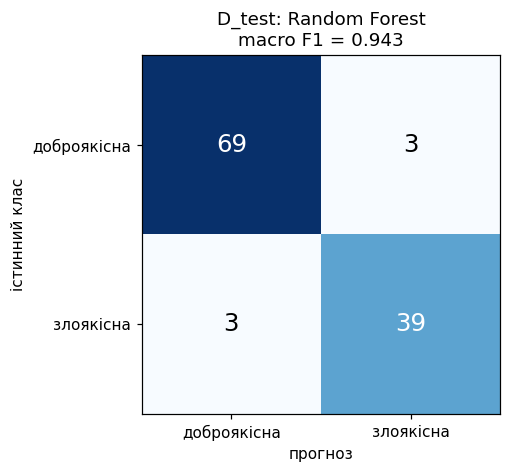

In [32]:
# ЄДИНЕ відкриття test set: одне навчання на всьому D_train, одна оцінка на D_test. Далі нічого не змінюється.
final_model = FACTORIES[FINAL_NAME]().fit(X_train, y_train)
y_pred = final_model.predict(X_test)
y_proba = final_model.predict_proba(X_test)[:, 1]
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()
test_metrics = {
    "macro_f1": f1_score(y_test, y_pred, average="macro"), "recall_malignant": recall_score(y_test, y_pred),
    "precision_malignant": precision_score(y_test, y_pred), "accuracy": accuracy_score(y_test, y_pred),
    "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
}
print(f"Модель: {LABELS[FINAL_NAME]}; |D_test| = {len(y_test)}")
print(pd.Series(test_metrics).round(4).to_string())
cv_f1 = summ.loc[FINAL_NAME]
print(f"\nДля порівняння, CV на D_train: macro F1 mean = {cv_f1['F1 mean']:.4f}, std = {cv_f1['F1 std']:.4f}, "
      f"min = {cv_f1['F1 min']:.4f}; recall(M) = {cv_f1['recall(M) val']:.4f}")
joblib.dump(final_model, RES / "final_model.joblib")
(RES / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2, default=float), encoding="utf-8")

fig, ax = plt.subplots(figsize=(4.8, 4.4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1], ["доброякісна", "злоякісна"])
ax.set_yticks([0, 1], ["доброякісна", "злоякісна"])
ax.set_xlabel("прогноз")
ax.set_ylabel("істинний клас")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=16,
                color="white" if cm[i, j] > cm.max() / 2 else "black")
ax.grid(False)
ax.set_title(f"D_test: {LABELS[FINAL_NAME]}\nmacro F1 = {test_metrics['macro_f1']:.3f}")
fig.tight_layout()
fig.savefig(FIG / "09_test_confusion_matrix.png", bbox_inches="tight")
plt.show()

In [33]:
err_idx = np.where(y_pred != y_test.values)[0]
ERR_FEATS = PDP_FEATURES + ["texture_worst"]
med = pd.DataFrame({"медіана M (train)": X_train.loc[y_train == 1, ERR_FEATS].median(),
                    "медіана B (train)": X_train.loc[y_train == 0, ERR_FEATS].median()})
print("Орієнтири (медіани класів у D_train):")
print(med.round(3).to_string())
err_tbl = X_test.iloc[err_idx][ERR_FEATS].copy()
err_tbl.insert(0, "тип", np.where(y_pred[err_idx] == 1, "FP (хибна тривога)", "FN (пропущена злоякісна)"))
err_tbl.insert(1, "P(malignant)", y_proba[err_idx])
print("Помилки на D_test:")
print(err_tbl.round(3).to_string())
conf = np.abs(y_proba - 0.5) * 2
ok = y_pred == y_test.values
print(f"Впевненість |2P−1|: правильні прогнози — медіана {np.median(conf[ok]):.3f}; помилки — {np.round(conf[~ok], 3).tolist()}")
gray = (y_proba > 0.3) & (y_proba < 0.7)
print(f"Об'єктів D_test з P(malignant) у «сірій зоні» 0.3–0.7: {int(gray.sum())}; серед них помилок: {int((gray & ~ok).sum())}")

Орієнтири (медіани класів у D_train):
                      медіана M (train)  медіана B (train)
concave_points_worst              0.183              0.072
radius_worst                     20.405             13.340
texture_worst                    28.645             22.740
Помилки на D_test:
                          тип  P(malignant)  concave_points_worst  radius_worst  texture_worst
363        FP (хибна тривога)         0.743                 0.091         18.13          25.45
541        FP (хибна тривога)         0.507                 0.120         16.22          31.73
406        FP (хибна тривога)         0.620                 0.113         17.71          19.58
41   FN (пропущена злоякісна)         0.313                 0.142         12.84          35.34
73   FN (пропущена злоякісна)         0.360                 0.138         16.57          20.86
385  FN (пропущена злоякісна)         0.327                 0.136         15.79          31.71
Впевненість |2P−1|: правильні прогнози — м

**Рис. 9** (`figures/09_test_confusion_matrix.png`; метрики — `results/test_metrics.json`; модель — `results/final_model.joblib`).

На $D_{test}$ (114 об'єктів, 42 злоякісних): **macro F1 = 0.9435**, recall злоякісних = 0.9286 (39 з 42), precision = 0.9286, accuracy = 0.9474; матриця: TN 69, FP 3, FN 3, TP 39.
CV-оцінка тієї ж моделі: 0.959 ± 0.017 (мінімум за folds 0.930) — тестовий результат трохи нижчий за середнє, але в межах розкиду між folds. На 114 об'єктах кожна помилка змінює recall на 2.4 п.п.,
тому відмінність від CV-оцінки не можна вважати свідченням проблеми; модель не змінюємо.

**Опис 6 помилок.**

* **FP (хибна тривога) — 3 об'єкти** (363, 541, 406): `radius_worst` 16.2–18.1 (медіана доброякісних у train 13.3, злоякісних 20.4) — **великі доброякісні ядра** з ділянки переходу PDP;
  `concave_points_worst` 0.09–0.12 (ближче до доброякісної медіани 0.072); P(malignant) 0.51–0.74.
* **FN (пропущені злоякісні) — 3 об'єкти** (41, 73, 385): `concave_points_worst` 0.136–0.142 (між медіанами класів 0.072 та 0.183), P(malignant) 0.31–0.36; `radius_worst` для двох із них 15.8–16.6 і 12.8 для третього — на доброякісному боці;
  ознаки текстури (`texture_worst` 31.7 та 35.3 у двох із них) вказують на злоякісність — це та інформація, яку RF використовує, але вона не переважила.
* Усі помилки — **низької впевненості** ($|2P-1|$ ≤ 0.49, а медіана для правильних прогнозів 0.98); 5 з 6 помилок припадає на 10 об'єктів із $P \in (0.3; 0.7)$. Практично це означає, що «сіра зона» ймовірностей
  є природним кандидатом на ручну перевірку. Тестові помилки схожі на межові об'єкти $D_{train}$ з розділу 10: нових типів помилок не виявлено.

## 13. Підсумки

| Гіпотеза | Вердикт | Ключове число |
|---|---|---|
| H1: RF краще за контрольоване дерево за macro F1 | **підтверджено (малий запас)** | Δ = 0.040 проти std дерева 0.033 |
| H2: прогнози RF стійкіші ≥ 3× | **підтверджено (малий запас)** | 3.56 % / 0.94 % = 3.79 (для HGB — 2.83) |
| H3: обмеження глибини зменшує розрив train–val | **підтверджено** | 0.091 → 0.060 (вкладена CV) / 0.021 (фікс.); але валідаційний F1 майже не змінився |
| H4: корінь bootstrap-дерев нестабільний | **підтверджено** | найчастіший корінь — 45 % (< 80 %) |
| H5: ранги impurity і PI розходяться для корельованих розмірних ознак | **підтверджено (за правилом)** | 4 з 6 мають $|\Delta\text{ранг}| \ge 5$; групова PI 0.261 проти суми 0.008 |

**Відповідь на головне питання.** Для цих даних перехід до ансамблю виправданий за якістю та стійкістю: Random Forest/HistGradientBoosting дають macro F1 ≈ 0.96 проти ≈ 0.92 у контрольованого дерева, вищий recall злоякісних
(0.94 проти 0.89), у кілька разів меншу чутливість прогнозу до розбиття та краще проходять «найгірший fold». Ціна — втрата єдиного читабельного набору правил для кожного прогнозу й приблизно у 80–90 разів більший час навчання й у 25–30 разів більший час прогнозу в однопотоковому вимірі (в абсолютних числах
незначний). Інтерпретація ансамблю (PI, PDP) стабільна лише на рівні груп корельованих ознак, а не окремих ознак; інтерпретація дерева нестабільна на рівні структури (корінь), але стабільна на рівні «що важливо взагалі»
(розмір ядра та увігнутість контуру).

**Обмеження.** Одна невелика вибірка (455 об'єктів для навчання, 114 для тесту); fold-оцінки з повторної CV не незалежні; невідомо, чи є кілька знімків одного пацієнта; параметри ансамблів фіксовані, а не оптимізовані;
вибір контрольованого дерева та пороги правил вибору моделі — це змістовні, але не єдино можливі рішення; різниця H1 і H2 над порогами невелика, тому висновки про перевагу ансамблю слід читати як «підтверджено в цьому експерименті», а не як універсальний.